In [278]:
import pandas as pd
import numpy as np
from pathlib import Path
from datetime import datetime, timedelta
import warnings

warnings.filterwarnings('ignore')

EVENTS_DIR = Path("/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/markets_enriched")
HOURLY_DIR = Path("/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/markets_hourly_data")
SPIKES_PATH = "/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/all_spikes_dataset.csv"
VAULTS_PATH = "/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/common/vaults_list.csv"
BORROWERS_SHARE_PATH = "/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/markets_borrowers_share.csv"
SUPPLIERS_SHARE_PATH = "/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/markets_suppliers_share.csv"


CRYPTO_MARKETS = [
    'eth_wbtc_usdc', 'base_wbtc_usdt', 'eth_cbbtc_usdc',
    'eth_wbtc_usdt', "eth_wsteth_usdt", 'eth_weth_usdt', 'eth_cbbtc_usdt',
]
PT_MARKETS = [
    "eth_PT-RLP-4SEP2025_usdc", "eth_PT-USD0++-27MAR2025_usdc",
    "eth_PT-USD0++-31OCT2024_usdc", "eth_PT-USDe-25SEP2025_dai",
    "eth_PT-USDe-25SEP2025_usdc", "eth_PT-USDe-25SEP2025_usdt",
    "eth_PT-USDe-27MAR2025_dai", "eth_PT-USDe-27NOV2025_usds",
    "eth_PT-USDe-31JUL2025_dai", "eth_PT-USR-29MAY2025_usdc",
    "eth_PT-csUSDL-31JUL2025_usdc", "eth_PT-lvlUSD-29MAY2025_usdc",
    "eth_PT-mHYPER-20NOV2025_usdc", "eth_PT-reUSD-18DEC2025_usdc",
    "eth_PT-reUSD-25JUN2026_usdc", "eth_PT-sNUSD-5MAR2026_usdc",
    "eth_PT-sdeUSD-1753142406_usdc", "eth_PT-slvlUSD-25SEP2025_usdc",
    "eth_PT-slvlUSD-29MAY2025_usdc", "eth_PT-stcUSD-23JUL2026_usdc",
    "eth_PT-stcUSD-29JAN2026_usdc", "eth_PT-syrupUSDC-28AUG2025_usdc",
    "eth_PT-syrupUSDC-30OCT2025_usdc", "eth_PT-wstUSR-25SEP2025_usdc",
    "eth_PT-wstUSR-27MAR2025_usdc", "eth_PT-wstUSR-27MAR2025_usr",
    "PT-reUSD-25JUN2026_usdc", "PT-siUSD-26MAR2026_usdc",
]
YB_TOKENS = [
    'eth_usr_usdc', 'eth_wsteth_usdc', 'eth_rlp_usdc',
    'eth_usd0++_usdc', 'eth_fxsave_usdc', 'eth_mapollo_usdc',
    'eth_wsrusd_usdc', 'eth_syrupusdc_pyusd', 'eth_susde_pyusd',
    'eth_stcusd_usdc', 'eth_usde_dai', 'eth_mhyper_usdc', 'eth_syrupusdc_usdc',
    'eth_wstusr_usdc','eth_slvlusd_usdc','eth_csusdl_usdc', 'eth_mF-ONE_usdc', 'eth_reusd_usdc',
    'eth_siusd_usdc', 'eth_sdeusd_usdc'
]




INTERESTING_MARKETS = PT_MARKETS



### **Create dataset**

In [ ]:
def load_spikes():
    df = pd.read_csv(SPIKES_PATH)
    df['spike_trigger_datetime'] = pd.to_datetime(df['spike_trigger_datetime'])
    df['spike_recovery_datetime'] = pd.to_datetime(df['spike_recovery_datetime'])
    print(df.isna().sum())
    df = df.dropna(subset=['spike_recovery_datetime'])
    df = df[df['market_name'].isin(INTERESTING_MARKETS)]
    return df

def load_all_events():
    dfs = []
    for market in INTERESTING_MARKETS:
        f = EVENTS_DIR / f"{market}.csv"
        if f.exists():
            df = pd.read_csv(f)
            df['market'] = market
            dfs.append(df)
    if not dfs:
        return pd.DataFrame()
    events = pd.concat(dfs, ignore_index=True)
    events['datetime'] = pd.to_datetime(events['datetime'])
    events = events.sort_values(['market', 'timestamp'])
    return events

def load_all_hourly():
    dfs = []
    for market in INTERESTING_MARKETS:
        f = HOURLY_DIR / f"{market}.csv"
        if f.exists():
            df = pd.read_csv(f)
            df['market'] = market
            dfs.append(df)
    if not dfs:
        return pd.DataFrame()
    hourly = pd.concat(dfs, ignore_index=True)
    hourly['datetime'] = pd.to_datetime(hourly['datetime'])
    hourly = hourly.sort_values(['market', 'timestamp'])
    return hourly

def load_borrowers_share():
    df = pd.read_csv(BORROWERS_SHARE_PATH)
    df['datetime'] = pd.to_datetime(df['datetime'])
    df = df[df['side'] == 'borrow'].copy()
    df = df[df['market'].isin(INTERESTING_MARKETS)]
    df = df.sort_values(['market', 'timestamp'])
    return df

def load_suppliers_share():
    df = pd.read_csv(SUPPLIERS_SHARE_PATH)
    df['datetime'] = pd.to_datetime(df['datetime'])
    df = df[df['side'] == 'supply'].copy()
    df = df[df['market'].isin(INTERESTING_MARKETS)]
    df = df.sort_values(['market', 'timestamp'])
    return df

def compute_hhi(shares_df_snapshot):
    if shares_df_snapshot.empty:
        return np.nan, np.nan, np.nan, np.nan
    top1 = shares_df_snapshot['share'].max() / 100.0
    top3 = shares_df_snapshot.nlargest(3, 'share')['share'].sum() / 100.0
    shares = shares_df_snapshot['share'].values / 100.0
    hhi = np.sum(shares ** 2)
    n_active = shares_df_snapshot['n_active'].iloc[0] if 'n_active' in shares_df_snapshot.columns else len(shares_df_snapshot)
    return top1, top3, hhi, n_active

def get_current_state_from_events(events_market, cutoff_dt):
    mask = events_market['datetime'] <= cutoff_dt
    if not mask.any():
        return None
    last_event = events_market.loc[mask].iloc[-1]
    return {
        'utilization': last_event.get('utilization_after', last_event.get('utilization_before')),
        'borrow_rate': last_event.get('borrow_rate_after', last_event.get('borrow_rate_before')),
        'supply_rate': last_event.get('supply_rate_after', last_event.get('supply_rate_before')),
        'total_borrow': last_event.get('total_borrow_after', last_event.get('total_borrow_before')),
        'total_supply': last_event.get('total_supply_after', last_event.get('total_supply_before')),
        'collateral_price': last_event.get('collateral_price'),
        'loan_asset_price': last_event.get('loan_asset_price')
    }

def get_hourly_snapshot(hourly_market, cutoff_dt):
    mask = hourly_market['datetime'] <= cutoff_dt
    if not mask.any():
        return None
    return hourly_market.loc[mask].iloc[-1]

def compute_price_features(hourly_market, cutoff_dt):
    mask = hourly_market['datetime'] <= cutoff_dt
    if mask.sum() < 2:
        return np.nan, np.nan, np.nan
    prices = hourly_market.loc[mask, 'collateral_price'].values
    if len(prices) == 0:
        return np.nan, np.nan, np.nan
    current_price = prices[-1]
    one_hour_ago = cutoff_dt - timedelta(hours=1)
    mask_1h = hourly_market['datetime'] <= one_hour_ago
    if mask_1h.any():
        price_1h = hourly_market.loc[mask_1h].iloc[-1]['collateral_price']
        return_1h = (current_price - price_1h) / price_1h if price_1h != 0 else np.nan
    else:
        return_1h = np.nan
    twenty_four_hours_ago = cutoff_dt - timedelta(hours=24)
    mask_24h = (hourly_market['datetime'] >= twenty_four_hours_ago) & (hourly_market['datetime'] <= cutoff_dt)
    prices_24h = hourly_market.loc[mask_24h, 'collateral_price']
    if len(prices_24h) > 1:
        vol_24h = prices_24h.pct_change().std() * np.sqrt(24)
    else:
        vol_24h = np.nan
    if len(prices) > 1:
        running_max = np.maximum.accumulate(prices)
        drawdown = (running_max[-1] - current_price) / running_max[-1] if running_max[-1] != 0 else 0
    else:
        drawdown = np.nan
    return return_1h, vol_24h, drawdown

def get_shares_snapshot(shares_market, cutoff_dt):
    mask = shares_market['datetime'] <= cutoff_dt
    if not mask.any():
        return pd.DataFrame()
    last_ts = shares_market.loc[mask, 'timestamp'].max()
    return shares_market[shares_market['timestamp'] == last_ts]
def preprocess_data_for_market(events_all, hourly_all, borrowers_share_all, spikes_all):
    events_by_market = {}
    for market, df in events_all.groupby('market'):
        df = df.sort_values('timestamp')
        events_by_market[market] = df.reset_index(drop=True)
    
    hourly_by_market = {}
    for market, df in hourly_all.groupby('market'):
        df = df.sort_values('timestamp')
        hourly_by_market[market] = df.reset_index(drop=True)
    
    shares_by_market = {}
    for market, df in borrowers_share_all.groupby('market'):
        df = df.sort_values('timestamp')
        ts_groups = {ts: sub_df.reset_index(drop=True) for ts, sub_df in df.groupby('timestamp')}
        shares_by_market[market] = {
            'timestamps': np.sort(list(ts_groups.keys())),
            'groups': ts_groups
        }
    
    spikes_by_market = {}
    for market, df in spikes_all.groupby('market_name'):
        df = df.sort_values('spike_trigger_datetime')
        spikes_by_market[market] = df.reset_index(drop=True)
    
    return events_by_market, hourly_by_market, shares_by_market, spikes_by_market

def get_last_row_before(df, cutoff_ts):
    idx = np.searchsorted(df['timestamp'].values, cutoff_ts, side='right') - 1
    if idx >= 0:
        return df.iloc[idx]
    return None

def get_shares_snapshot_opt(shares_data, cutoff_ts):
    ts_array = shares_data['timestamps']
    idx = np.searchsorted(ts_array, cutoff_ts, side='right') - 1
    if idx >= 0:
        ts = ts_array[idx]
        return shares_data['groups'][ts]
    return pd.DataFrame()

def compute_spike_features_opt(spike_row, events_market, hourly_market, shares_data, market_spikes_df):
    spike_start = spike_row['spike_trigger_datetime']
    spike_end = spike_row['spike_recovery_datetime']
    cutoff_dt = spike_row['cutoff_dt']
    time_offset_minutes = (cutoff_dt - spike_start).total_seconds() / 60.0
    
    spike_start_ts = spike_start.timestamp()
    spike_end_ts = spike_end.timestamp()
    cutoff_ts = cutoff_dt.timestamp()
    
    state_start_row = get_last_row_before(events_market, spike_start_ts)
    state_current_row = get_last_row_before(events_market, cutoff_ts)
    
    utilization_start = state_start_row['utilization_after'] if state_start_row is not None and 'utilization_after' in state_start_row else (state_start_row.get('utilization_before') if state_start_row is not None else np.nan)
    utilization_current = state_current_row['utilization_after'] if state_current_row is not None and 'utilization_after' in state_current_row else (state_current_row.get('utilization_before') if state_current_row is not None else np.nan)
    borrow_rate_start = state_start_row['borrow_rate_after'] if state_start_row is not None and 'borrow_rate_after' in state_start_row else (state_start_row.get('borrow_rate_before') if state_start_row is not None else np.nan)
    total_borrow_current = state_current_row['total_borrow_after'] if state_current_row is not None and 'total_borrow_after' in state_current_row else (state_current_row.get('total_borrow_before') if state_current_row is not None else np.nan)
    
    util_col = 'utilization_after' if 'utilization_after' in events_market.columns else 'utilization_before'
    events_during_mask = (events_market['timestamp'] > spike_start_ts) & (events_market['timestamp'] <= cutoff_ts)
    utilization_peak_so_far = events_market.loc[events_during_mask, util_col].max() if events_during_mask.any() else utilization_current
    if pd.isna(utilization_peak_so_far):
        utilization_peak_so_far = utilization_current
    
    rate_slope_1h = np.nan
    if time_offset_minutes >= 0:
        cutoff_1h_ts = (spike_start + timedelta(hours=1)).timestamp()
        state_1h_row = get_last_row_before(events_market, cutoff_1h_ts)
        if state_1h_row is not None and borrow_rate_start is not None:
            rate_1h = state_1h_row.get('borrow_rate_after', state_1h_row.get('borrow_rate_before', np.nan))
            if not pd.isna(rate_1h):
                rate_slope_1h = (borrow_rate_start - rate_1h) / 1.0
    
    spread_to_base_rate = np.nan
    mask_24h_before = (events_market['timestamp'] < spike_start_ts) & (events_market['timestamp'] >= spike_start_ts - 86400)
    if mask_24h_before.any():
        avg_rate_24h = events_market.loc[mask_24h_before, 'borrow_rate_before'].mean()
        if not pd.isna(borrow_rate_start):
            spread_to_base_rate = borrow_rate_start - avg_rate_24h
    
    shares_snapshot = get_shares_snapshot_opt(shares_data, cutoff_ts)
    top1, top3, hhi, n_active = compute_hhi(shares_snapshot)
    
    price_return_1h, price_volatility_24h, drawdown = np.nan, np.nan, np.nan
    hourly_cutoff_idx = np.searchsorted(hourly_market['timestamp'].values, cutoff_ts, side='right') - 1
    if hourly_cutoff_idx >= 0:
        current_price = hourly_market.iloc[hourly_cutoff_idx]['collateral_price']
        start_1h_idx = np.searchsorted(hourly_market['timestamp'].values, cutoff_ts - 3600, side='right') - 1
        if start_1h_idx >= 0:
            price_1h = hourly_market.iloc[start_1h_idx]['collateral_price']
            if price_1h != 0:
                price_return_1h = (current_price - price_1h) / price_1h
        start_24h_idx = np.searchsorted(hourly_market['timestamp'].values, cutoff_ts - 86400, side='left')
        if hourly_cutoff_idx >= start_24h_idx:
            prices_24h = hourly_market.iloc[start_24h_idx:hourly_cutoff_idx+1]['collateral_price'].values
            if len(prices_24h) > 1:
                price_volatility_24h = np.std(np.diff(np.log(prices_24h))) * np.sqrt(24)
            running_max = np.maximum.accumulate(prices_24h)
            if running_max[-1] != 0:
                drawdown = (running_max[-1] - current_price) / running_max[-1]
    
    start_24h_h_idx = np.searchsorted(hourly_market['timestamp'].values, spike_start_ts - 86400, side='left')
    pre_spike_hourly = hourly_market.iloc[start_24h_h_idx:np.searchsorted(hourly_market['timestamp'].values, spike_start_ts, side='left')]
    avg_util_24h_before = pre_spike_hourly['utilization'].mean() if len(pre_spike_hourly) > 0 else np.nan
    avg_rate_24h_before = pre_spike_hourly['borrow_rate'].mean() if len(pre_spike_hourly) > 0 else np.nan
    
    if market_spikes_df is not None and len(market_spikes_df) > 0:
        spike_start_dt = spike_row['spike_trigger_datetime']
        past_mask = market_spikes_df['spike_trigger_datetime'] < spike_start_dt
        past_spikes = market_spikes_df.loc[past_mask, 'spike_trigger_datetime']
        last_7d_mask = past_spikes >= spike_start_dt - timedelta(days=7)
        num_spikes_last_7d = last_7d_mask.sum()
        time_since_last_spike = (spike_start_dt - past_spikes.max()).total_seconds() if len(past_spikes) > 0 else np.nan
    else:
        num_spikes_last_7d = 0
        time_since_last_spike = np.nan
    
    remaining_seconds = spike_end_ts - cutoff_ts
    
    return {
        'market': spike_row['market_name'],
        'spike_index': spike_row.name,
        'time_offset_minutes': time_offset_minutes,
        'utilization_start': utilization_start,
        'utilization_current': utilization_current,
        'utilization_peak_so_far': utilization_peak_so_far,
        'borrow_rate_start': borrow_rate_start,
        'rate_slope_1h': rate_slope_1h,
        'spread_to_base_rate': spread_to_base_rate,
        'total_borrow_current': total_borrow_current,
        'n_active_borrowers': n_active,
        'top1_share': top1,
        'top3_share': top3,
        'hhi': hhi,
        'price_return_1h': price_return_1h,
        'price_volatility_24h': price_volatility_24h,
        'drawdown': drawdown,
        'avg_utilization_24h_before': avg_util_24h_before,
        'avg_rate_24h_before': avg_rate_24h_before,
        'num_spikes_last_7d': num_spikes_last_7d,
        'time_since_last_spike': time_since_last_spike,
        'remaining_duration_seconds': remaining_seconds,
        'spike_duration_seconds': spike_row['spike_duration_seconds'],
        'cutoff_timestamp': cutoff_ts,
        'spike_trigger_timestamp': spike_start_ts
    }

def build_spike_modeling_dataset():
    print("Loading data...")
    spikes = load_spikes()
    events = load_all_events()
    hourly = load_all_hourly()
    borrowers_share = load_borrowers_share()
    
    print("Preprocessing data per market...")
    events_by_market, hourly_by_market, shares_by_market, spikes_by_market = preprocess_data_for_market(
        events, hourly, borrowers_share, spikes
    )

    print(shares_by_market.keys())
    
    print(f"Spikes with recovery: {len(spikes)}")
    
    rows = []
    for idx, spike in spikes.reset_index().iterrows():
        if idx % 200 == 0:
            print(f"Processing spike {idx}...")
        market = spike['market_name']
        start = spike['spike_trigger_datetime']
        end = spike['spike_recovery_datetime']
        duration_minutes = (end - start).total_seconds() / 60.0
        
        try:
            events_m = events_by_market[market]
            hourly_m = hourly_by_market[market]
            shares_m = shares_by_market[market]
        except Exception as e:
            print("SKIPPING", market)
        market_spikes = spikes_by_market.get(market)
        
        intervals = np.arange(0, duration_minutes, 30)
        for offset in intervals:
            cutoff = start + timedelta(minutes=float(offset))
            spike_row = spike.copy()
            spike_row['cutoff_dt'] = cutoff
            # try:
            feats = compute_spike_features_opt(spike_row, events_m, hourly_m, shares_m, market_spikes)
            rows.append(feats)
            # except Exception as e:
            #     print(f"Error at spike {idx} offset {offset}: {e}")
            #     continue
        cutoff = end
        spike_row = spike.copy()
        spike_row['cutoff_dt'] = cutoff
        try:
            feats = compute_spike_features_opt(spike_row, events_m, hourly_m, shares_m, market_spikes)
            rows.append(feats)
        except Exception as e:
            print(f"Error at spike {idx} end: {e}")

    result_df = pd.DataFrame(rows)
    return result_df

In [304]:
load_suppliers_share()

,market,timestamp,datetime,side,user_address,share,total,hhi,n_active
1431774,PT-reUSD-25JUN2026_usdc,1765296899,2025-12-09 16:14:59,supply,0x201051Ae0FddaC0Ce47B299E4673cAA39f32A961,100.000000,0.002000,1.000000,1
1431775,PT-reUSD-25JUN2026_usdc,1765297019,2025-12-09 16:16:59,supply,0x201051Ae0FddaC0Ce47B299E4673cAA39f32A961,100.000000,0.022000,1.000000,1
1431776,PT-reUSD-25JUN2026_usdc,1765565675,2025-12-12 18:54:35,supply,0x201051Ae0FddaC0Ce47B299E4673cAA39f32A961,100.000000,0.022000,1.000000,1
1431777,PT-reUSD-25JUN2026_usdc,1765566347,2025-12-12 19:05:47,supply,0x201051Ae0FddaC0Ce47B299E4673cAA39f32A961,100.000000,0.022000,1.000000,1
1431778,PT-reUSD-25JUN2026_usdc,1765567847,2025-12-12 19:30:47,supply,0x201051Ae0FddaC0Ce47B299E4673cAA39f32A961,100.000000,0.022000,1.000000,1
...,...,...,...,...,...,...,...,...,...
1431769,eth_PT-wstUSR-27MAR2025_usr,1743785399,2025-04-04 16:49:59,supply,0x9e26C43019276872d9E20f847AC1923502715314,47.583373,0.021016,0.501168,12
1431770,eth_PT-wstUSR-27MAR2025_usr,1743785399,2025-04-04 16:49:59,supply,other,0.000004,0.021016,0.501168,12
1431771,eth_PT-wstUSR-27MAR2025_usr,1743790175,2025-04-04 18:09:35,supply,0x06590Fef209Ebc1f8eEF83dA05984cD4eFf0d0E3,52.416624,0.021016,0.501168,12
1431772,eth_PT-wstUSR-27MAR2025_usr,1743790175,2025-04-04 18:09:35,supply,0x9e26C43019276872d9E20f847AC1923502715314,47.583373,0.021016,0.501168,12


In [280]:
df = build_spike_modeling_dataset()
print(f"Dataset shape: {df.shape}")
df.head(3)

Loading data...
market_name                      0
market_address                   0
max_total_supply                 0
market_total_events              0
market_n_users                   0
market_n_spikes                  0
spike_index                      0
spike_trigger_datetime           0
spike_recovery_datetime          0
spike_duration_seconds           0
spike_magnitude_util_delta       0
peak_utilization                 0
trigger_event_types              0
total_borrow_before              0
total_supply_before              0
utilization_before               0
collateral_price               393
loan_asset_price                 0
debt_before                      0
supply_before                 1300
n_total_events_in_spike          0
n_repay_events_in_spike          0
dtype: int64
Preprocessing data per market...
dict_keys(['PT-reUSD-25JUN2026_usdc', 'PT-siUSD-26MAR2026_usdc', 'eth_PT-RLP-4SEP2025_usdc', 'eth_PT-USD0++-27MAR2025_usdc', 'eth_PT-USD0++-31OCT2024_usdc', 'eth_PT-USD

,market,spike_index,time_offset_minutes,utilization_start,utilization_current,utilization_peak_so_far,borrow_rate_start,rate_slope_1h,spread_to_base_rate,total_borrow_current,n_active_borrowers,top1_share,top3_share,hhi,price_return_1h,price_volatility_24h,drawdown,avg_utilization_24h_before,avg_rate_24h_before,num_spikes_last_7d,time_since_last_spike,remaining_duration_seconds,spike_duration_seconds,cutoff_timestamp,spike_trigger_timestamp
0,eth_PT-reUSD-25JUN2026_usdc,0,0.0,0.998929,0.998929,0.998929,0.244128,-0.000135,0.170115,6.686546e+06,4,0.844331,1.0,0.736842,0.000000,0.019151,0.000759,0.902505,0.110877,0,NaN,14208.0,14208,1.765619e+09,1.765619e+09
1,eth_PT-reUSD-25JUN2026_usdc,0,30.0,0.998929,0.999557,0.999557,0.244128,-0.000135,0.170115,6.690781e+06,4,0.843800,1.0,0.735918,0.001426,0.019138,0.000000,0.902505,0.110877,0,NaN,12408.0,14208,1.765621e+09,1.765619e+09
2,eth_PT-reUSD-25JUN2026_usdc,0,60.0,0.998929,0.998811,0.999557,0.244128,-0.000135,0.170115,6.690878e+06,4,0.843800,1.0,0.735918,0.001426,0.019138,0.000000,0.902505,0.110877,0,NaN,10608.0,14208,1.765623e+09,1.765619e+09


In [ ]:
# df.to_csv("/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/modelling_datasets/spikes_modeling_df_yb_tokens.csv", index=False)
# df.to_csv("/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/modelling_datasets/spikes_modeling_df_PT_tokens.csv", index=False)
# df.to_csv("/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/modelling_datasets/spikes_modeling_df_CRYPTO_tokens.csv", index=False)

# df = pd.read_csv("/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/modelling_datasets/spikes_modeling_df_PT_tokens.csv")

### **Regression models - duration (baseline)**

In [276]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import matplotlib.pyplot as plt

def prepare_spike_dataset(df_long):
    df_first = df_long[df_long['time_offset_minutes'] == 0].copy()
    df_first['spike_duration_minutes'] = df_first['spike_duration_seconds'] / 60.0
    feature_cols = [
        'utilization_start', 'utilization_peak_so_far', 'borrow_rate_start',
        'rate_slope_1h', 'spread_to_base_rate', 'total_borrow_current',
        'n_active_borrowers', 'top1_share', 'top3_share', 'hhi',
        'price_return_1h', 'price_volatility_24h', 'drawdown',
        'avg_utilization_24h_before', 'avg_rate_24h_before',
        'num_spikes_last_7d', 'time_since_last_spike'
    ]
    X = df_first[feature_cols].fillna(0)
    y = df_first['spike_duration_minutes']
    return X, y, df_first

def split_data(X, y, test_size=0.2, val_size=0.1, random_state=42):
    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )
    val_ratio = val_size / (1 - test_size)
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=val_ratio, random_state=random_state
    )
    return X_train, X_val, X_test, y_train, y_val, y_test

def train_linear_regression(X_train, y_train, X_val, y_val):
    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_val = model.predict(X_val)
    return model, y_pred_train, y_pred_val

def train_xgboost(X_train, y_train, X_val, y_val):
    model = xgb.XGBRegressor(
        n_estimators=100,
        max_depth=4,
        learning_rate=0.1,
        random_state=42
    )
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_val = model.predict(X_val)
    return model, y_pred_train, y_pred_val



def report_linear_coefficients(model, feature_names, X_train, y_train):
    from scipy import stats
    
    n = len(y_train)
    p = len(feature_names)
    y_pred = model.predict(X_train)
    rss = np.sum((y_train - y_pred) ** 2)
    sigma2 = rss / (n - p - 1)
    
    X_with_const = np.column_stack([np.ones(len(X_train)), X_train])
    cov_matrix = sigma2 * np.linalg.inv(X_with_const.T @ X_with_const)
    se = np.sqrt(np.diag(cov_matrix))[1:]
    
    t_stats = model.coef_ / se
    p_values = 2 * (1 - stats.t.cdf(np.abs(t_stats), n - p - 1))
    
    coef_df = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': model.coef_,
        'Std_Error': se,
        't_statistic': t_stats,
        'p_value': p_values,
        'Significant': p_values < 0.05
    }).sort_values('p_value')
    
    print("\nLinear Regression Coefficients & Significance:")
    print(coef_df.to_string(index=False))
    
    plt.figure(figsize=(10, 6))
    colors = ['green' if p < 0.05 else 'red' for p in coef_df['p_value']]
    plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, alpha=0.7)
    plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    plt.xlabel('Coefficient Value')
    plt.title('Linear Regression Coefficients (green = p<0.05)')
    plt.tight_layout()
    plt.show()
    
    return coef_df

def report_xgboost_importance(model, feature_names):
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    importance_df['Importance_pct'] = importance_df['Importance'] / importance_df['Importance'].sum() * 100
    
    print("\nXGBoost Feature Importance:")
    print(importance_df.to_string(index=False))
    
    plt.figure(figsize=(10, 6))
    plt.barh(importance_df['Feature'], importance_df['Importance_pct'], alpha=0.7, color='steelblue')
    plt.xlabel('Importance (%)')
    plt.title('XGBoost Feature Importance')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    return importance_df


def evaluate_model(y_true, y_pred, model_name, quantile_cut=0.95):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    print(f"\n{model_name} Performance:")
    print(f"MAE: {mae:.2f} min")
    print(f"RMSE: {rmse:.2f} min")
    print(f"R²: {r2:.4f}")
    
    cap = np.quantile(y_true, quantile_cut)
    mask = (y_true <= cap) & (y_pred <= cap)
    y_true_plot = y_true[mask]
    y_pred_plot = y_pred[mask]
    
    plt.figure(figsize=(6, 5))
    plt.scatter(y_true_plot, y_pred_plot, alpha=0.6, edgecolors='k', linewidth=0.5)
    max_val = max(y_true_plot.max(), y_pred_plot.max())
    plt.plot([0, max_val], [0, max_val], 'r--', label='Perfect prediction')
    plt.xlabel('Actual duration (minutes)')
    plt.ylabel('Predicted duration (minutes)')
    plt.title(f'{model_name}: Predicted vs Actual\n(≤ {quantile_cut*100:.0f}th percentile)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return {'mae': mae, 'rmse': rmse, 'r2': r2}

Training Linear Regression...

Linear Regression Performance:
MAE: 145.89 min
RMSE: 361.58 min
R²: 0.0781


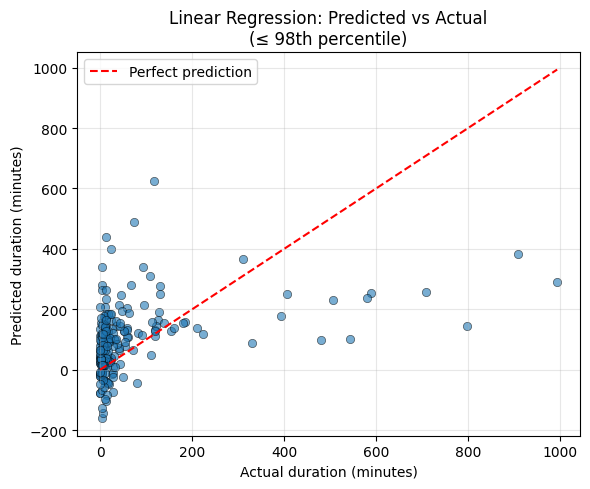


Training XGBoost...

XGBoost Performance:
MAE: 108.07 min
RMSE: 341.03 min
R²: 0.1799


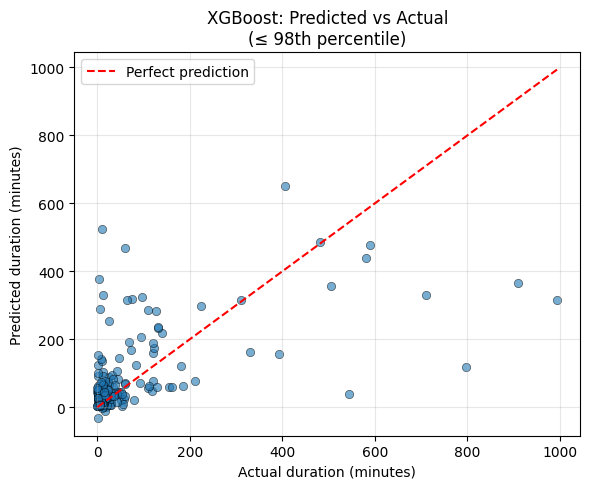


Test set evaluation (XGBoost):

XGBoost (Test) Performance:
MAE: 104.72 min
RMSE: 253.08 min
R²: 0.3087


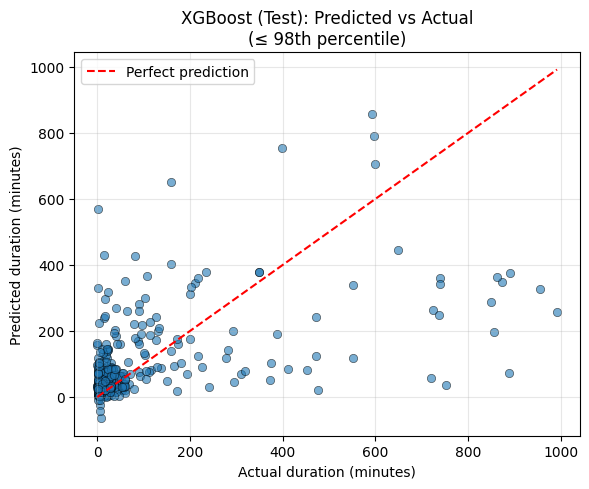

In [244]:
X, y, df_spikes = prepare_spike_dataset(df)

X_train, X_val, X_test, y_train, y_val, y_test = split_data(X, y, test_size=0.2, val_size=0.1, random_state=42)

print("Training Linear Regression...")
lr_model, lr_train_pred, lr_val_pred = train_linear_regression(X_train, y_train, X_val, y_val)
lr_metrics = evaluate_model(y_val, lr_val_pred, "Linear Regression", quantile_cut=0.98)

print("\nTraining XGBoost...")
xgb_model, xgb_train_pred, xgb_val_pred = train_xgboost(X_train, y_train, X_val, y_val)
xgb_metrics = evaluate_model(y_val, xgb_val_pred, "XGBoost", quantile_cut=0.98)

print("\nTest set evaluation (XGBoost):")
y_test_pred = xgb_model.predict(X_test)
test_metrics = evaluate_model(y_test, y_test_pred, "XGBoost (Test)", quantile_cut=0.98)



МЕТРИКИ КАЧЕСТВА МОДЕЛЕЙ НА ВСЕХ ВЫБОРКАХ

Train:
  Linear Regression -> MAE=743.82 min, RMSE=1330.01 min, R²=0.1891, MAPE=6482.45%
  XGBoost           -> MAE=345.60 min, RMSE=609.14 min, R²=0.8299, MAPE=3145.17%

Val:
  Linear Regression -> MAE=597.26 min, RMSE=1017.58 min, R²=0.2106, MAPE=10538.77%
  XGBoost           -> MAE=445.66 min, RMSE=895.54 min, R²=0.3886, MAPE=4357.21%

Test:
  Linear Regression -> MAE=766.31 min, RMSE=1698.62 min, R²=0.1331, MAPE=5813.81%
  XGBoost           -> MAE=607.94 min, RMSE=1505.06 min, R²=0.3194, MAPE=2998.93%

ИНТЕРПРЕТАЦИЯ МОДЕЛЕЙ

Linear Regression Coefficients & Significance:
                   Feature   Coefficient    Std_Error   t_statistic      p_value  Significant
             rate_slope_1h -9.134330e+03 1.754672e+03 -5.205718e+00 2.419852e-07         True
       avg_rate_24h_before -7.123015e+03 2.495217e+03 -2.854667e+00 4.412026e-03         True
       spread_to_base_rate  3.685287e+03 1.635390e+03  2.253460e+00 2.448188e-02         Tru

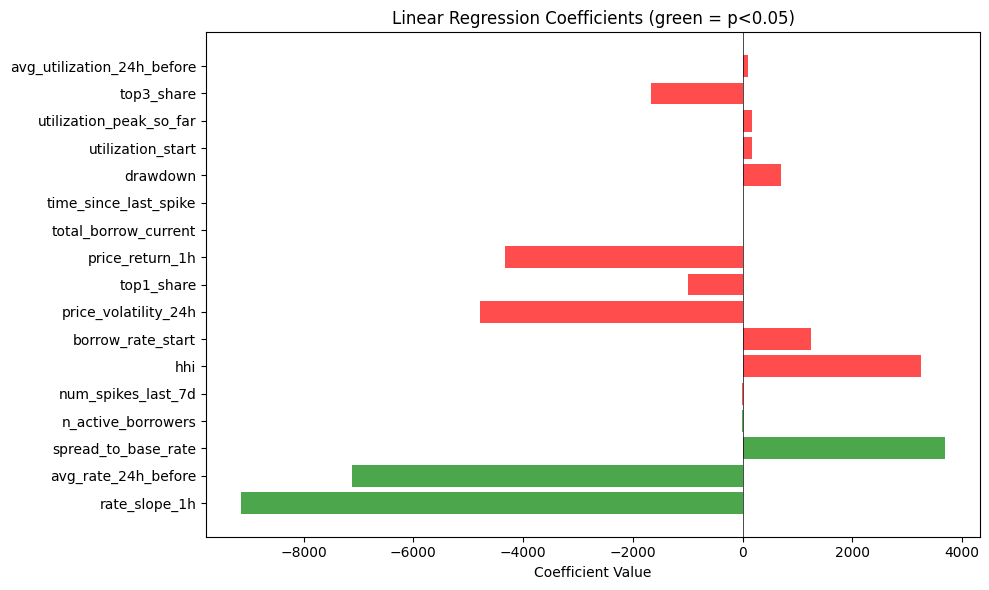


XGBoost Feature Importance:
                   Feature  Importance  Importance_pct
        n_active_borrowers    0.134210       13.421042
             rate_slope_1h    0.120277       12.027691
      price_volatility_24h    0.098971        9.897080
        num_spikes_last_7d    0.074893        7.489301
       avg_rate_24h_before    0.061937        6.193691
      total_borrow_current    0.061866        6.186567
     time_since_last_spike    0.061764        6.176365
avg_utilization_24h_before    0.057322        5.732231
                top1_share    0.051523        5.152331
       spread_to_base_rate    0.049329        4.932939
                       hhi    0.047925        4.792504
                top3_share    0.044486        4.448630
         borrow_rate_start    0.037558        3.755771
         utilization_start    0.035018        3.501842
           price_return_1h    0.031532        3.153196
                  drawdown    0.031388        3.138818
   utilization_peak_so_far    0.0000

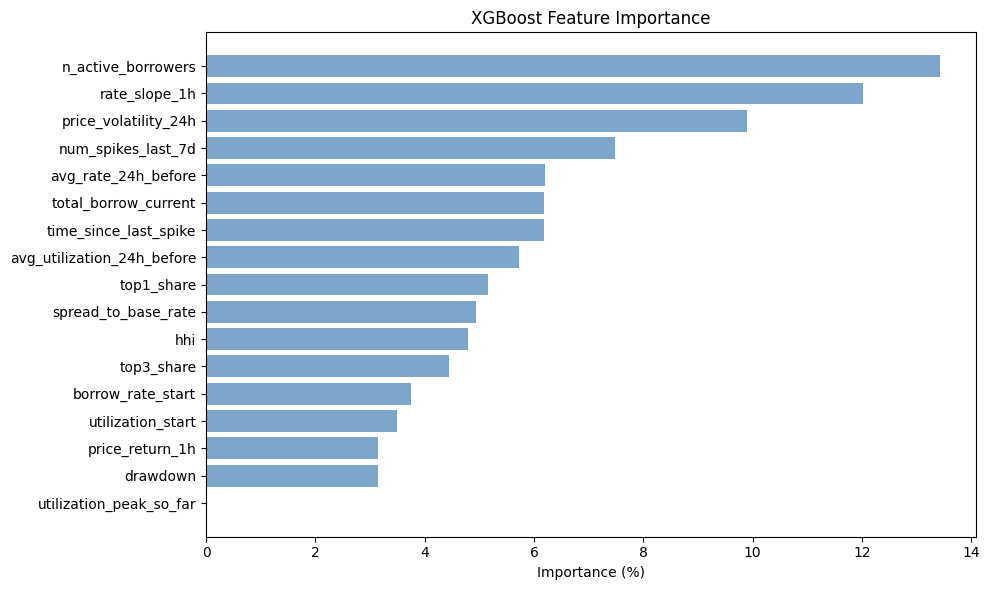

,Feature,Importance,Importance_pct
6,n_active_borrowers,0.134210,13.421042
3,rate_slope_1h,0.120277,12.027691
11,price_volatility_24h,0.098971,9.897080
15,num_spikes_last_7d,0.074893,7.489301
14,avg_rate_24h_before,0.061937,6.193691
5,total_borrow_current,0.061866,6.186567
16,time_since_last_spike,0.061764,6.176365
13,avg_utilization_24h_before,0.057322,5.732231
7,top1_share,0.051523,5.152331
4,spread_to_base_rate,0.049329,4.932939


In [277]:

# ------------------------------------------------------------
# Основной блок: обучение и оценка
# Предполагаем, что df_long уже загружен
# ------------------------------------------------------------
X, y, df_first = prepare_spike_dataset(df)
X_train, X_val, X_test, y_train, y_val, y_test = split_data(X, y)

# Линейная регрессия
lr_model, y_pred_train_lr, y_pred_val_lr = train_linear_regression(X_train, y_train, X_val, y_val)
y_pred_test_lr = lr_model.predict(X_test)

# XGBoost
xgb_model, y_pred_train_xgb, y_pred_val_xgb = train_xgboost(X_train, y_train, X_val, y_val)
y_pred_test_xgb = xgb_model.predict(X_test)

# Функция для расчёта метрик (включая MAPE)
def compute_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    # MAPE – избегаем деления на 0
    mask = y_true > 1e-6
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    return mae, rmse, r2, mape

# Вывод по всем выборкам
print("\n" + "="*80)
print("МЕТРИКИ КАЧЕСТВА МОДЕЛЕЙ НА ВСЕХ ВЫБОРКАХ")
print("="*80)
for name, y_true, y_pred_lr, y_pred_xgb in [
    ("Train", y_train, y_pred_train_lr, y_pred_train_xgb),
    ("Val",   y_val,   y_pred_val_lr,   y_pred_val_xgb),
    ("Test",  y_test,  y_pred_test_lr,  y_pred_test_xgb)
]:
    lr_mae, lr_rmse, lr_r2, lr_mape = compute_metrics(y_true, y_pred_lr)
    xgb_mae, xgb_rmse, xgb_r2, xgb_mape = compute_metrics(y_true, y_pred_xgb)
    print(f"\n{name}:")
    print(f"  Linear Regression -> MAE={lr_mae:.2f} min, RMSE={lr_rmse:.2f} min, R²={lr_r2:.4f}, MAPE={lr_mape:.2f}%")
    print(f"  XGBoost           -> MAE={xgb_mae:.2f} min, RMSE={xgb_rmse:.2f} min, R²={xgb_r2:.4f}, MAPE={xgb_mape:.2f}%")

# Дополнительно: коэффициенты линейной модели и важность XGBoost
print("\n" + "="*80)
print("ИНТЕРПРЕТАЦИЯ МОДЕЛЕЙ")
print("="*80)
report_linear_coefficients(lr_model, X.columns, X_train, y_train)
report_xgboost_importance(xgb_model, X.columns)



Linear Regression Coefficients & Significance:
                   Feature   Coefficient    Std_Error  t_statistic      p_value  Significant
avg_utilization_24h_before -1.407083e+03 1.356046e+02   -10.376361 0.000000e+00         True
             rate_slope_1h -1.005168e+03 1.351988e+02    -7.434745 1.803002e-13         True
        num_spikes_last_7d -2.979501e+00 5.783155e-01    -5.152033 2.939322e-07         True
                       hhi -1.485745e+00 4.809477e-01    -3.089202 2.045891e-03         True
        n_active_borrowers -8.354938e-01 4.113557e-01    -2.031074 4.243345e-02         True
                top3_share  1.037809e+02 6.867181e+01     1.511258 1.309451e-01        False
      total_borrow_current  1.811064e-07 2.593562e-07     0.698292 4.851088e-01        False
       avg_rate_24h_before  3.465986e+02 5.049639e+02     0.686383 4.925837e-01        False
      price_volatility_24h -2.637857e+02 4.229400e+02    -0.623695 5.329279e-01        False
         utilization_s

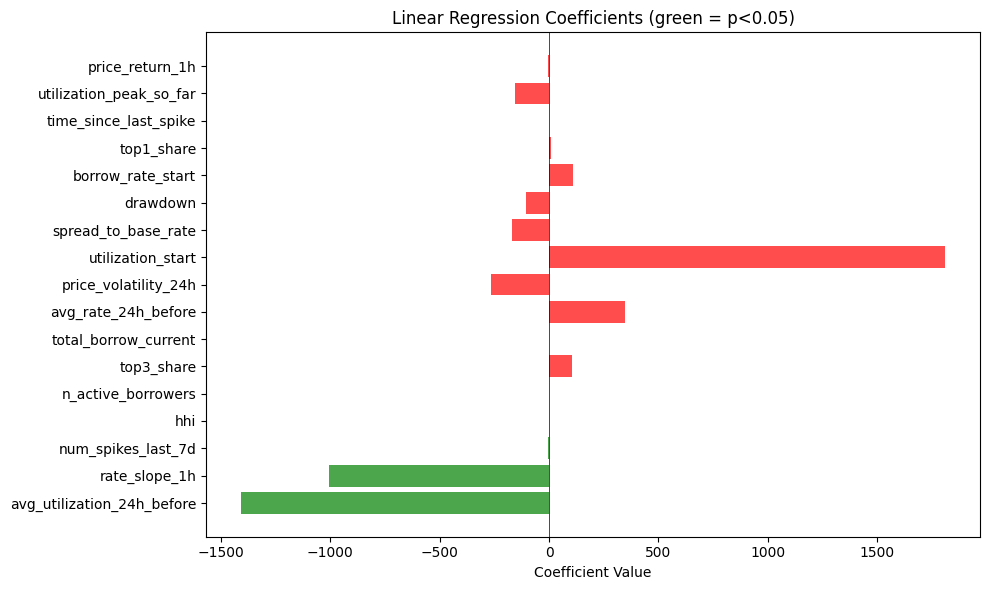


XGBoost Feature Importance:
                   Feature  Importance  Importance_pct
        n_active_borrowers    0.200087       20.008728
avg_utilization_24h_before    0.150034       15.003441
             rate_slope_1h    0.087674        8.767433
      price_volatility_24h    0.085226        8.522577
     time_since_last_spike    0.073441        7.344141
       avg_rate_24h_before    0.065232        6.523204
        num_spikes_last_7d    0.049893        4.989285
                top3_share    0.045184        4.518373
       spread_to_base_rate    0.039690        3.969006
                       hhi    0.031156        3.115553
                top1_share    0.030403        3.040286
         utilization_start    0.030172        3.017177
                  drawdown    0.029737        2.973731
      total_borrow_current    0.029584        2.958448
         borrow_rate_start    0.029565        2.956476
   utilization_peak_so_far    0.017101        1.710096
           price_return_1h    0.0058

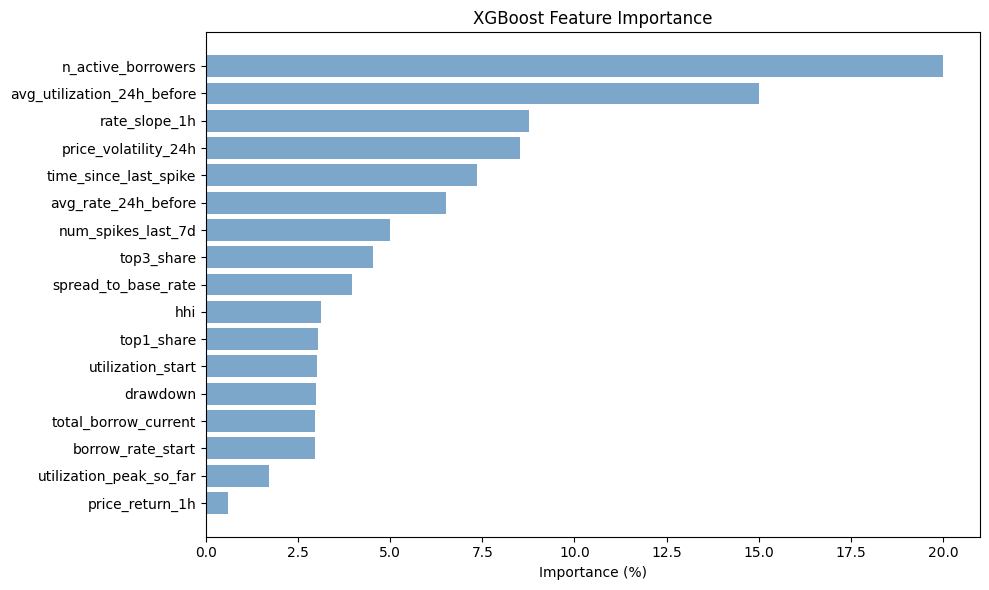

In [170]:
feature_names = X.columns.tolist()

lr_coef_df = report_linear_coefficients(lr_model, feature_names, X_train, y_train)

xgb_imp_df = report_xgboost_importance(xgb_model, feature_names)


### **Classification models - whether spike was closed before 1 hours / n hours**

In [171]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
import statsmodels.api as sm
import optuna

def prepare_classification_dataset(df_long, threshold_minutes=60):
    df_first = df_long[df_long['time_offset_minutes'] == 0].copy()
    df_first['spike_duration_minutes'] = df_first['spike_duration_seconds'] / 60.0
    df_first['target'] = (df_first['spike_duration_minutes'] > threshold_minutes).astype(int)
    
    feature_cols = [
        'utilization_start', 'utilization_peak_so_far', 'borrow_rate_start',
        'rate_slope_1h', 'spread_to_base_rate', 'total_borrow_current',
        'n_active_borrowers', 'top1_share', 'top3_share', 'hhi',
        'price_return_1h', 'price_volatility_24h', 'drawdown',
        'avg_utilization_24h_before', 'avg_rate_24h_before',
        'num_spikes_last_7d', 'time_since_last_spike'
    ]
    X = df_first[feature_cols].fillna(0)
    y = df_first['target']
    return X, y, df_first

def train_logistic_regression(X_train, y_train, X_val, y_val):
    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_proba_train = model.predict_proba(X_train)[:, 1]
    y_pred_val = model.predict(X_val)
    y_pred_proba_val = model.predict_proba(X_val)[:, 1]
    return model, y_pred_train, y_pred_proba_train, y_pred_val, y_pred_proba_val

def report_logistic_coefficients(model, feature_names, X_train, y_train):
    X_with_const = sm.add_constant(X_train)
    logit_model = sm.Logit(y_train, X_with_const)
    result = logit_model.fit(disp=0)
    
    coef_df = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': result.params[1:].values,
        'Std_Error': result.bse[1:].values,
        'z_statistic': result.tvalues[1:].values,
        'p_value': result.pvalues[1:].values,
        'Significant': result.pvalues[1:].values < 0.05
    }).sort_values('p_value')
    
    print("\nLogistic Regression Coefficients & Significance:")
    print(coef_df.to_string(index=False))
    
    plt.figure(figsize=(10, 6))
    colors = ['green' if p < 0.05 else 'red' for p in coef_df['p_value']]
    plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, alpha=0.7)
    plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    plt.xlabel('Coefficient Value')
    plt.title('Logistic Regression Coefficients (green = p<0.05)')
    plt.tight_layout()
    plt.show()
    
    return coef_df

def evaluate_classification(y_true, y_pred, y_pred_proba, model_name):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc = roc_auc_score(y_true, y_pred_proba)
    
    print(f"\n{model_name} Performance:")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"ROC AUC:   {auc:.4f}")
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(f'{model_name} - Confusion Matrix')
    plt.colorbar()
    tick_marks = [0, 1]
    plt.xticks(tick_marks, ['Short (≤1h)', 'Long',])
    plt.yticks(tick_marks, ['Short (≤1h)', 'Long',])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    for i in range(2):
        for j in range(2):
            plt.text(j, i, str(cm[i, j]), ha='center', va='center', color='white' if cm[i, j] > cm.max()/2 else 'black')
    plt.tight_layout()
    plt.show()
    
    fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
    plt.figure(figsize=(5, 4))
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc:.3f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()
    
    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1, 'auc': auc}

def train_xgboost_classifier(X_train, y_train, X_val, y_val, use_optuna=False, n_trials=50):
    if use_optuna:
        def objective(trial):
            class_weight_param = trial.suggest_float('class_weight', 1, 50, log=True)
            
            params = {
                'n_estimators': trial.suggest_int('n_estimators', 50, 300),
                'max_depth': trial.suggest_int('max_depth', 3, 10),
                'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
                'subsample': trial.suggest_float('subsample', 0.6, 1.0),
                'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
                'gamma': trial.suggest_float('gamma', 0, 5),
                'reg_alpha': trial.suggest_float('reg_alpha', 1e-5, 1.0, log=True),
                'reg_lambda': trial.suggest_float('reg_lambda', 1e-5, 1.0, log=True),
                'random_state': 42,
                'use_label_encoder': False,
                'eval_metric': 'logloss',
                # 'scale_pos_weight': class_weight_param
            }
            model = xgb.XGBClassifier(**params)
            model.fit(X_train, y_train)
            y_pred_proba = model.predict_proba(X_val)[:, 1]
            auc = roc_auc_score(y_val, y_pred_proba)
            rec = recall_score(y_val, model.predict(X_val), zero_division=0)
            return rec
        
        study = optuna.create_study(direction='maximize')
        study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
        best_params = study.best_params
        best_params['random_state'] = 42
        model = xgb.XGBClassifier(**best_params, use_label_encoder=False, eval_metric='logloss')
        print(f"Best Optuna params: {study.best_params}")
    else:
        model = xgb.XGBClassifier(
            n_estimators=100, max_depth=4, learning_rate=0.1,
            random_state=42, use_label_encoder=False, eval_metric='logloss'
        )
    
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_proba_train = model.predict_proba(X_train)[:, 1]
    y_pred_val = model.predict(X_val)
    y_pred_proba_val = model.predict_proba(X_val)[:, 1]
    return model, y_pred_train, y_pred_proba_train, y_pred_val, y_pred_proba_val

def report_xgboost_classifier_importance(model, feature_names):
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': model.feature_importances_
    }).sort_values('Importance', ascending=False)
    importance_df['Importance_pct'] = importance_df['Importance'] / importance_df['Importance'].sum() * 100
    
    print("\nXGBoost Classifier Feature Importance:")
    print(importance_df.to_string(index=False))
    
    plt.figure(figsize=(10, 6))
    plt.barh(importance_df['Feature'], importance_df['Importance_pct'], alpha=0.7, color='steelblue')
    plt.xlabel('Importance (%)')
    plt.title('XGBoost Classifier Feature Importance')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    return importance_df


=== Logistic Regression ===

Logistic Regression Performance:
Accuracy:  0.7767
Precision: 0.6000
Recall:    0.0638
F1 Score:  0.1154
ROC AUC:   0.7197


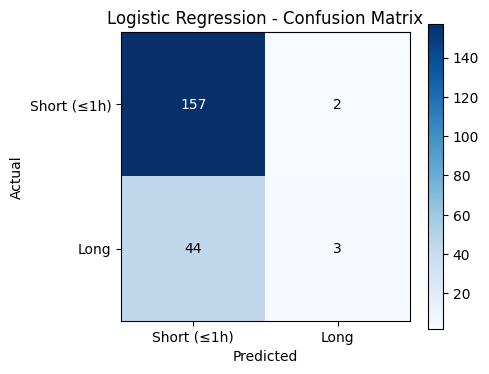

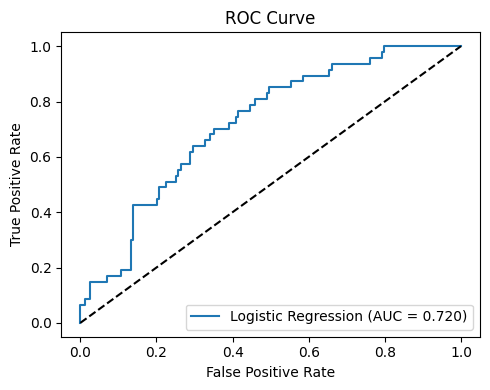


Logistic Regression Coefficients & Significance:
                   Feature   Coefficient    Std_Error  z_statistic      p_value  Significant
             rate_slope_1h -2.432262e+01 1.853529e+00   -13.122329 2.452802e-39         True
        num_spikes_last_7d -3.752691e-02 8.694733e-03    -4.316051 1.588456e-05         True
       spread_to_base_rate  1.911205e+01 5.511498e+00     3.467668 5.249958e-04         True
                top3_share  2.417817e+00 7.145351e-01     3.383762 7.150005e-04         True
                top1_share -1.836301e+00 5.944553e-01    -3.089049 2.007985e-03         True
avg_utilization_24h_before -3.515078e+00 1.311004e+00    -2.681211 7.335619e-03         True
                       hhi -1.215242e-02 5.624718e-03    -2.160538 3.073101e-02         True
     time_since_last_spike  8.688924e-07 4.059595e-07     2.140343 3.232707e-02         True
      price_volatility_24h -1.752159e+01 8.236369e+00    -2.127344 3.339153e-02         True
      total_borrow_c

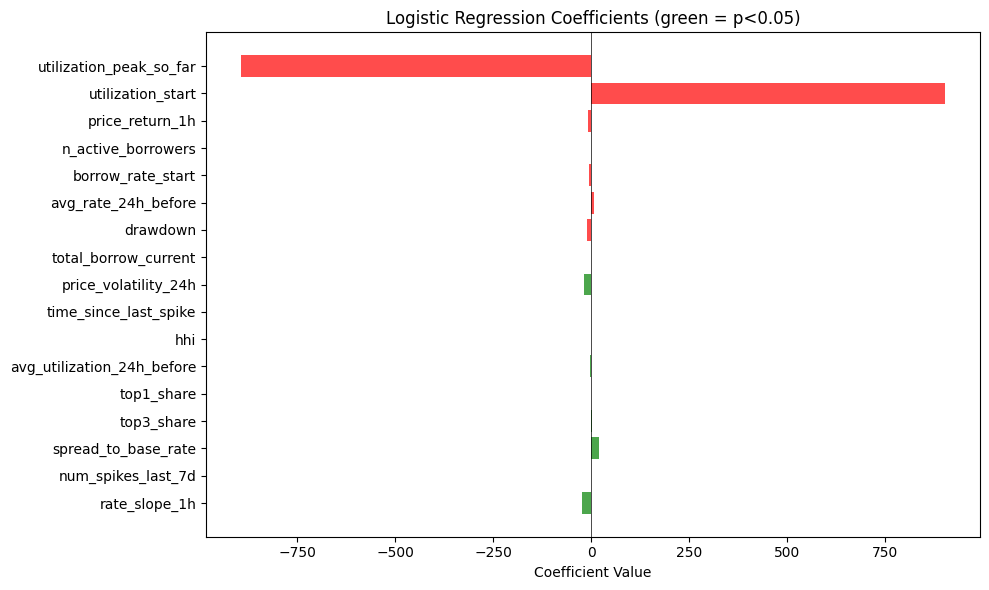


=== XGBoost Classifier (without Optuna) ===

XGBoost Classifier Performance:
Accuracy:  0.8981
Precision: 0.8095
Recall:    0.7234
F1 Score:  0.7640
ROC AUC:   0.9409


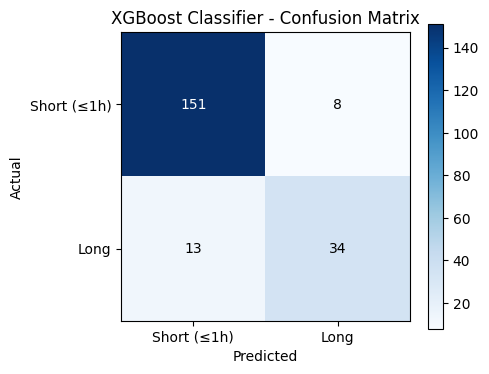

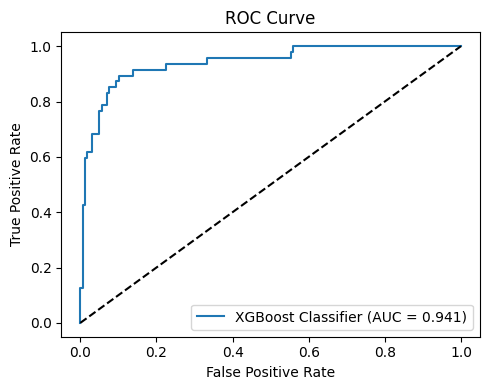


XGBoost Classifier Feature Importance:
                   Feature  Importance  Importance_pct
             rate_slope_1h    0.209246       20.924635
        num_spikes_last_7d    0.089223        8.922316
       spread_to_base_rate    0.080601        8.060094
         borrow_rate_start    0.061877        6.187733
                  drawdown    0.058969        5.896935
         utilization_start    0.055223        5.522346
avg_utilization_24h_before    0.052688        5.268829
                       hhi    0.046207        4.620710
           price_return_1h    0.041977        4.197722
                top1_share    0.041738        4.173789
     time_since_last_spike    0.040969        4.096859
       avg_rate_24h_before    0.040745        4.074483
      total_borrow_current    0.038456        3.845622
      price_volatility_24h    0.037829        3.782923
                top3_share    0.037350        3.734961
        n_active_borrowers    0.035279        3.527915
   utilization_peak_so_fa

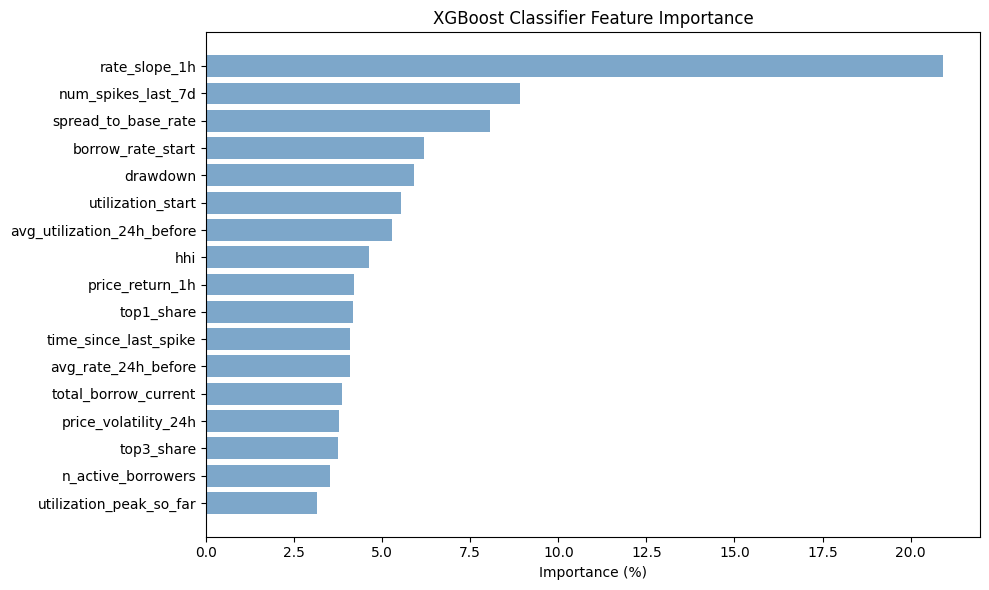

[I 2026-04-21 15:03:23,793] A new study created in memory with name: no-name-4fe8ae00-29b1-4bba-8e48-572892d7790c



=== XGBoost Classifier (with Optuna) ===


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-04-21 15:03:24,110] Trial 0 finished with value: 0.6808510638297872 and parameters: {'class_weight': 10.500766725810339, 'n_estimators': 171, 'max_depth': 5, 'learning_rate': 0.023132747582285774, 'subsample': 0.839338894613762, 'colsample_bytree': 0.8782496889317755, 'gamma': 2.042574650011975, 'reg_alpha': 1.176551165854301e-05, 'reg_lambda': 0.0005265483617036534}. Best is trial 0 with value: 0.6808510638297872.
[I 2026-04-21 15:03:24,583] Trial 1 finished with value: 0.6808510638297872 and parameters: {'class_weight': 48.92136206955759, 'n_estimators': 268, 'max_depth': 8, 'learning_rate': 0.01220289210349816, 'subsample': 0.9010363259933853, 'colsample_bytree': 0.9806902207630804, 'gamma': 3.321977389389583, 'reg_alpha': 2.2020881606830506e-05, 'reg_lambda': 0.0016954144941651985}. Best is trial 0 with value: 0.6808510638297872.
[I 2026-04-21 15:03:24,684] Trial 2 finished with value: 0.7021276595744681 and parameters: {'class_weight': 6.9542623168404, 'n_estimators': 84, 

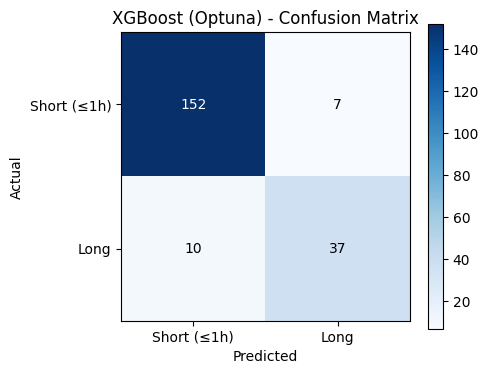

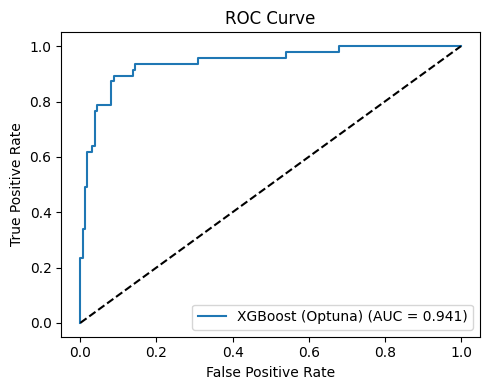

In [172]:
X_cls, y_cls, df_spikes_cls = prepare_classification_dataset(df, threshold_minutes=60)

X_train_c, X_val_c, X_test_c, y_train_c, y_val_c, y_test_c = split_data(
    X_cls, y_cls, test_size=0.2, val_size=0.1, random_state=42
)

print("\n=== Logistic Regression ===")
lr_cls, lr_train_pred, lr_train_proba, lr_val_pred, lr_val_proba = train_logistic_regression(
    X_train_c, y_train_c, X_val_c, y_val_c
)
lr_cls_metrics = evaluate_classification(y_val_c, lr_val_pred, lr_val_proba, "Logistic Regression")
lr_coef = report_logistic_coefficients(lr_cls, X_cls.columns.tolist(), X_train_c, y_train_c)

print("\n=== XGBoost Classifier (without Optuna) ===")
xgb_cls, xgb_train_pred, xgb_train_proba, xgb_val_pred, xgb_val_proba = train_xgboost_classifier(
    X_train_c, y_train_c, X_val_c, y_val_c, use_optuna=False
)
xgb_metrics = evaluate_classification(y_val_c, xgb_val_pred, xgb_val_proba, "XGBoost Classifier")
xgb_imp = report_xgboost_classifier_importance(xgb_cls, X_cls.columns.tolist())

print("\n=== XGBoost Classifier (with Optuna) ===")
xgb_opt, _, _, xgb_opt_val_pred, xgb_opt_val_proba = train_xgboost_classifier(
    X_train_c, y_train_c, X_val_c, y_val_c, use_optuna=True, n_trials=30
)
opt_metrics = evaluate_classification(y_val_c, xgb_opt_val_pred, xgb_opt_val_proba, "XGBoost (Optuna)")


Market: Volatile collateral

--- Logistic Regression ---

--- XGBoost (Optuna) ---
XGBoost best params: {'n_estimators': 299, 'max_depth': 6, 'learning_rate': 0.02501387768064264, 'subsample': 0.9115065272524447, 'colsample_bytree': 0.8672815689895866, 'gamma': 0.3429686203104764, 'reg_alpha': 0.002439083963000238, 'reg_lambda': 0.003165872870136352, 'random_state': 42, 'use_label_encoder': False, 'eval_metric': 'logloss'}

--- CatBoost (Optuna) ---
CatBoost best params: {'iterations': 287, 'depth': 8, 'learning_rate': 0.06617873821521947, 'l2_leaf_reg': 3.9890748540596963, 'border_count': 164, 'random_seed': 42, 'verbose': False, 'eval_metric': 'AUC'}

--- Test Performance Summary ---
          Accuracy  Precision_long  Recall_long  F1_long  AUC-ROC  AUC-PR
Model                                                                    
LogReg      0.5777          0.5766       0.5203   0.5470   0.6201  0.5831
XGBoost     0.8327          0.8189       0.8455   0.8320   0.9167  0.9063
CatBoost

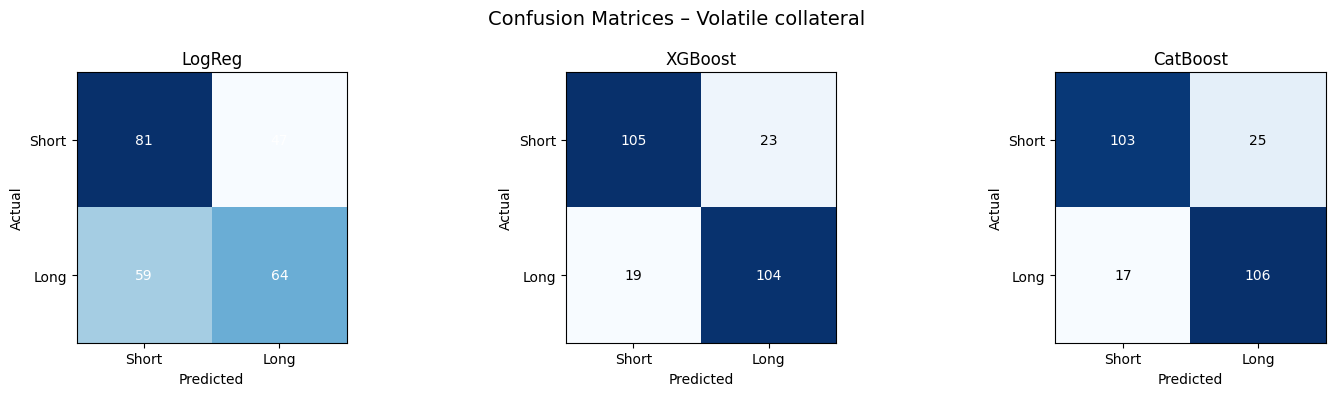

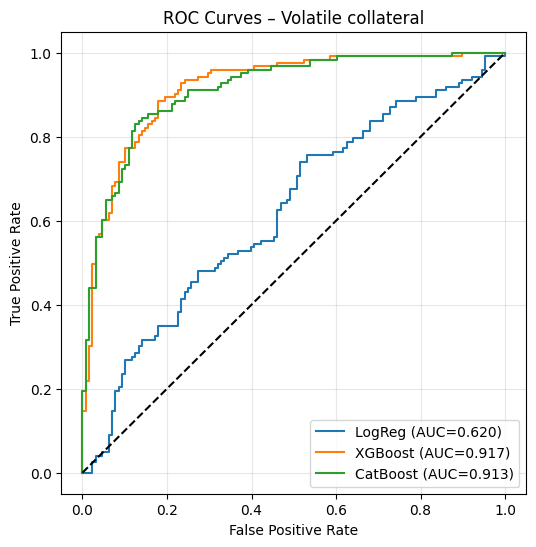


Market: YB collateral

--- Logistic Regression ---

--- XGBoost (Optuna) ---
XGBoost best params: {'n_estimators': 266, 'max_depth': 9, 'learning_rate': 0.14641770468896617, 'subsample': 0.8296004451927201, 'colsample_bytree': 0.8946530686573855, 'gamma': 0.7505926525070121, 'reg_alpha': 0.005571269332403903, 'reg_lambda': 1.0718249788126599e-05, 'random_state': 42, 'use_label_encoder': False, 'eval_metric': 'logloss'}

--- CatBoost (Optuna) ---
CatBoost best params: {'iterations': 157, 'depth': 7, 'learning_rate': 0.07653621388853392, 'l2_leaf_reg': 4.0461410329145595, 'border_count': 178, 'random_seed': 42, 'verbose': False, 'eval_metric': 'AUC'}

--- Test Performance Summary ---
          Accuracy  Precision_long  Recall_long  F1_long  AUC-ROC  AUC-PR
Model                                                                    
LogReg      0.8401          0.8333       0.0294   0.0568   0.6138  0.2870
XGBoost     0.8940          0.7174       0.5824   0.6429   0.9178  0.7282
CatBoost    

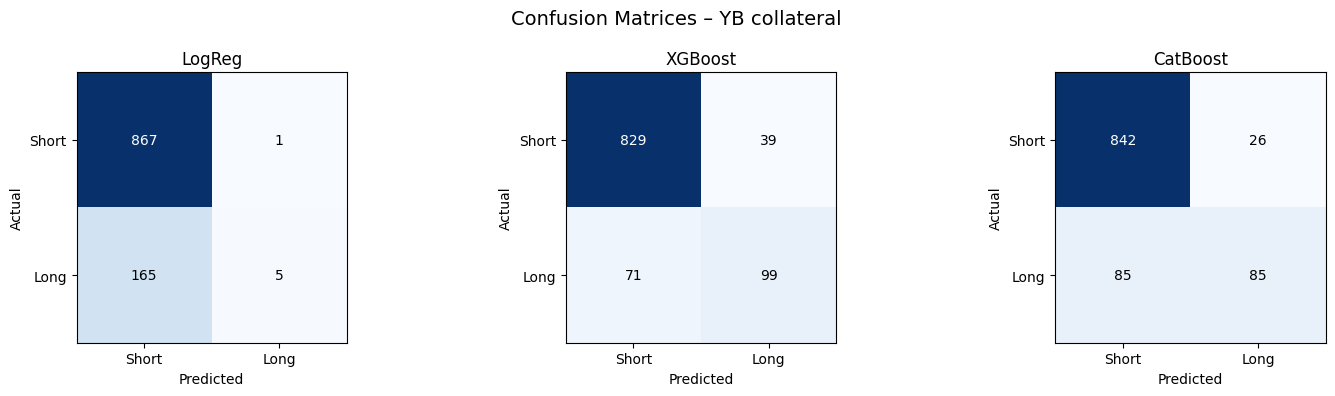

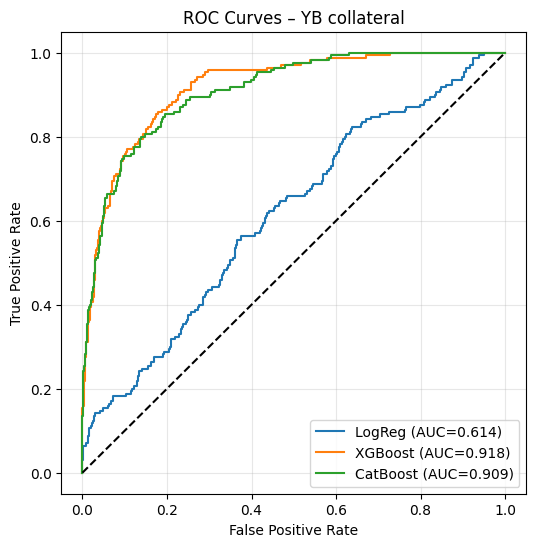


Market: PT collateral

--- Logistic Regression ---

--- XGBoost (Optuna) ---
XGBoost best params: {'n_estimators': 262, 'max_depth': 10, 'learning_rate': 0.018180160739509725, 'subsample': 0.9018862955358474, 'colsample_bytree': 0.6107095073844375, 'gamma': 1.1905512391847863, 'reg_alpha': 0.01188440409424519, 'reg_lambda': 4.159655487543998e-05, 'random_state': 42, 'use_label_encoder': False, 'eval_metric': 'logloss'}

--- CatBoost (Optuna) ---
CatBoost best params: {'iterations': 206, 'depth': 3, 'learning_rate': 0.11559716146329733, 'l2_leaf_reg': 9.840850402840134, 'border_count': 33, 'random_seed': 42, 'verbose': False, 'eval_metric': 'AUC'}

--- Test Performance Summary ---
          Accuracy  Precision_long  Recall_long  F1_long  AUC-ROC  AUC-PR
Model                                                                    
LogReg      0.7579          0.5000       0.0280   0.0531   0.7204  0.4238
XGBoost     0.8891          0.8816       0.6262   0.7322   0.9375  0.8751
CatBoost    0.

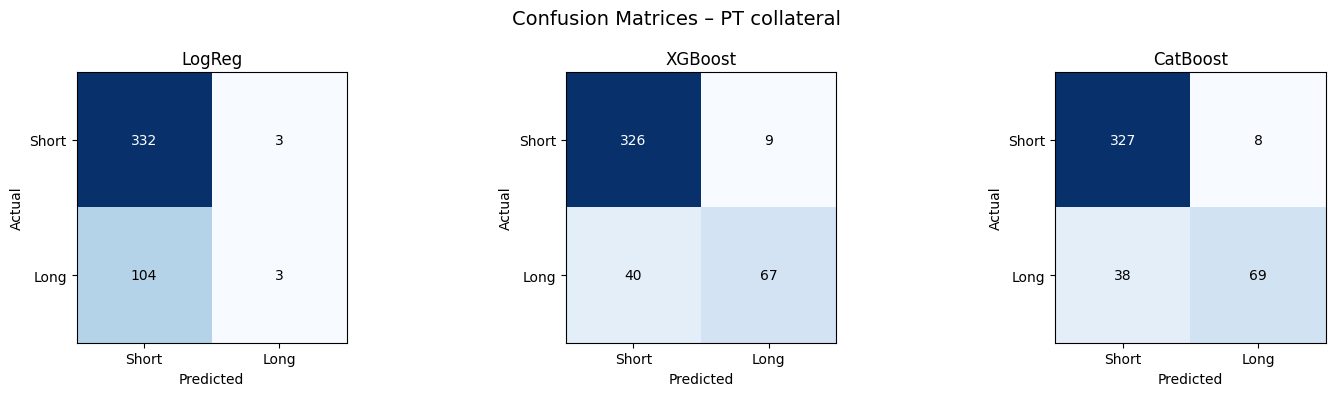

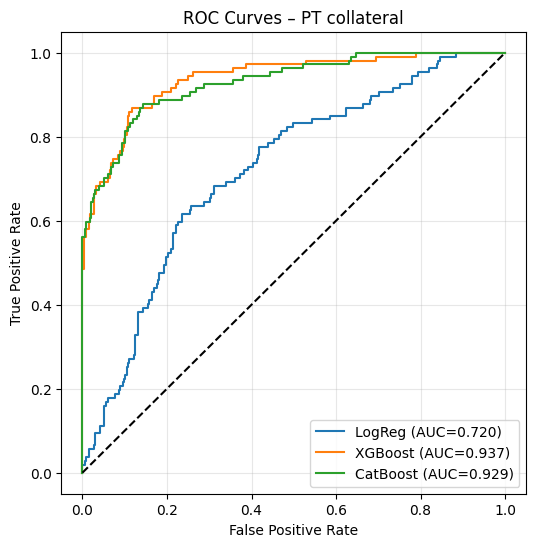

,Accuracy,Precision_long,Recall_long,F1_long,AUC-ROC,AUC-PR
Model,,,,,,
LogReg,0.757919,0.500000,0.028037,0.053097,0.720407,0.423772
XGBoost,0.889140,0.881579,0.626168,0.732240,0.937453,0.875071
CatBoost,0.895928,0.896104,0.644860,0.750000,0.929223,0.869197


In [290]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, average_precision_score
)
import statsmodels.api as sm
import optuna
import xgboost as xgb
from catboost import CatBoostClassifier
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Подготовка данных
# ------------------------------------------------------------
def prepare_classification_dataset(df_long, threshold_minutes=60):
    df_first = df_long[df_long['time_offset_minutes'] == 0].copy()
    df_first['spike_duration_minutes'] = df_first['spike_duration_seconds'] / 60.0
    df_first['target'] = (df_first['spike_duration_minutes'] > threshold_minutes).astype(int)

    feature_cols = [
        'utilization_start', 'borrow_rate_start',
        'rate_slope_1h', 'spread_to_base_rate', 'total_borrow_current',
        'n_active_borrowers', 'top1_share', 'top3_share', 'hhi',
        'price_return_1h', 'price_volatility_24h', 'drawdown',
        'avg_utilization_24h_before', 'avg_rate_24h_before',
        'num_spikes_last_7d', 'time_since_last_spike'
    ]
    X = df_first[feature_cols].fillna(0)
    y = df_first['target']
    return X, y, feature_cols

def split_data(X, y, test_size=0.2, val_size=0.1, random_state=42):
    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )
    val_ratio = val_size / (1 - test_size)
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=val_ratio, random_state=random_state
    )
    return X_train, X_val, X_test, y_train, y_val, y_test

# ------------------------------------------------------------
# Модели с оптимизацией (кроме логистической регрессии)
# ------------------------------------------------------------
def train_logistic_regression(X_train, y_train):
    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_train, y_train)
    return model

def train_xgboost_optuna(X_train, y_train, X_val, y_val, n_trials=30):
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 300),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'gamma': trial.suggest_float('gamma', 0, 5),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-5, 1.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-5, 1.0, log=True),
            'random_state': 42,
            'use_label_encoder': False,
            'eval_metric': 'logloss'
        }
        model = xgb.XGBClassifier(**params)
        model.fit(X_train, y_train)
        y_pred_proba = model.predict_proba(X_val)[:, 1]
        return roc_auc_score(y_val, y_pred_proba)

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    best_params = study.best_params
    best_params.update({'random_state': 42, 'use_label_encoder': False, 'eval_metric': 'logloss'})
    model = xgb.XGBClassifier(**best_params)
    model.fit(X_train, y_train)
    print(f"XGBoost best params: {best_params}")
    return model

def train_catboost_optuna(X_train, y_train, X_val, y_val, n_trials=30):
    def objective(trial):
        params = {
            'iterations': trial.suggest_int('iterations', 50, 300),
            'depth': trial.suggest_int('depth', 3, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
            'border_count': trial.suggest_int('border_count', 32, 255),
            'random_seed': 42,
            'verbose': False,
            'eval_metric': 'AUC'
        }
        model = CatBoostClassifier(**params)
        model.fit(X_train, y_train)
        y_pred_proba = model.predict_proba(X_val)[:, 1]
        return roc_auc_score(y_val, y_pred_proba)

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    best_params = study.best_params
    best_params.update({'random_seed': 42, 'verbose': False, 'eval_metric': 'AUC'})
    model = CatBoostClassifier(**best_params)
    model.fit(X_train, y_train)
    print(f"CatBoost best params: {best_params}")
    return model

# ------------------------------------------------------------
# Метрики
# ------------------------------------------------------------
def compute_metrics(y_true, y_pred, y_proba):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision_long': precision_score(y_true, y_pred, zero_division=0),
        'Recall_long': recall_score(y_true, y_pred, zero_division=0),
        'F1_long': f1_score(y_true, y_pred, zero_division=0),
        'AUC-ROC': roc_auc_score(y_true, y_proba),
        'AUC-PR': average_precision_score(y_true, y_proba)
    }

# ------------------------------------------------------------
# Основной эксперимент для одного типа рынка
# ------------------------------------------------------------
def run_classification_experiment(df_long, market_label, n_trials=30):
    print(f"\n{'='*60}")
    print(f"Market: {market_label}")
    X, y, feature_names = prepare_classification_dataset(df_long)
    X_train, X_val, X_test, y_train, y_val, y_test = split_data(X, y)

    results = {}

    # LogReg (без оптимизации)
    print("\n--- Logistic Regression ---")
    lr = train_logistic_regression(X_train, y_train)
    y_test_pred = lr.predict(X_test)
    y_test_proba = lr.predict_proba(X_test)[:, 1]
    results['LogReg'] = compute_metrics(y_test, y_test_pred, y_test_proba)

    # XGBoost (Optuna)
    print("\n--- XGBoost (Optuna) ---")
    xgb_model = train_xgboost_optuna(X_train, y_train, X_val, y_val, n_trials)
    y_test_pred1 = xgb_model.predict(X_test)
    y_test_proba1 = xgb_model.predict_proba(X_test)[:, 1]
    results['XGBoost'] = compute_metrics(y_test, y_test_pred1, y_test_proba1)

    # CatBoost (Optuna)
    print("\n--- CatBoost (Optuna) ---")
    cb_model = train_catboost_optuna(X_train, y_train, X_val, y_val, n_trials)
    y_test_pred2 = cb_model.predict(X_test)
    y_test_proba2 = cb_model.predict_proba(X_test)[:, 1]
    results['CatBoost'] = compute_metrics(y_test, y_test_pred2, y_test_proba2)

    # Сводка
    summary = pd.DataFrame(results).T
    summary.index.name = 'Model'
    print("\n--- Test Performance Summary ---")
    print(summary.round(4).to_string())

    # Визуализации
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    models_plot = [('LogReg', lr, y_test_pred), ('XGBoost', xgb_model, y_test_pred1),
                   ('CatBoost', cb_model, y_test_pred2)]
    for ax, (name, model, preds) in zip(axes, models_plot):
        cm = confusion_matrix(y_test, preds)
        im = ax.imshow(cm, cmap='Blues')
        ax.set_title(name)
        ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
        ax.set_xticks([0,1]); ax.set_yticks([0,1])
        ax.set_xticklabels(['Short','Long']); ax.set_yticklabels(['Short','Long'])
        for i in range(2):
            for j in range(2):
                ax.text(j, i, str(cm[i,j]), ha='center', va='center',
                        color='white' if cm[i,j] > cm.max()/2 else 'black')
    fig.suptitle(f'Confusion Matrices – {market_label}', fontsize=14)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6,6))
    for name, model, proba in [('LogReg', lr, y_test_proba),
                               ('XGBoost', xgb_model, y_test_proba1),
                               ('CatBoost', cb_model, y_test_proba2)]:
        fpr, tpr, _ = roc_curve(y_test, proba)
        auc = roc_auc_score(y_test, proba)
        plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
    plt.plot([0,1],[0,1],'k--')
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curves – {market_label}')
    plt.legend(loc='lower right'); plt.grid(alpha=0.3)
    plt.show()

    return summary

# ------------------------------------------------------------
# Пример запуска (замените на свои датафреймы)
# ------------------------------------------------------------
# Допустим, df_volatile, df_yb, df_pt уже содержат данные одного типа рынка.
# summary_vol = run_classification_experiment(df_volatile, 'Volatile collateral')
# summary_yb   = run_classification_experiment(df_yb, 'YB')
# summary_pt   = run_classification_experiment(df_pt, 'PT')

df = pd.read_csv("/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/modelling_datasets/spikes_modeling_df_CRYPTO_tokens.csv")
run_classification_experiment(df, "Volatile collateral", n_trials=30)

df = pd.read_csv("/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/modelling_datasets/spikes_modeling_df_YB_tokens.csv")
run_classification_experiment(df, "YB collateral", n_trials=30)

df = pd.read_csv("/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/modelling_datasets/spikes_modeling_df_PT_tokens.csv")
run_classification_experiment(df, "PT collateral", n_trials=30)


### **Hazard modeling (bins)**

In [132]:
print(list(range(0, 60*24, 30)))

[0, 30, 60, 90, 120, 150, 180, 210, 240, 270, 300, 330, 360, 390, 420, 450, 480, 510, 540, 570, 600, 630, 660, 690, 720, 750, 780, 810, 840, 870, 900, 930, 960, 990, 1020, 1050, 1080, 1110, 1140, 1170, 1200, 1230, 1260, 1290, 1320, 1350, 1380, 1410]


In [299]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import brier_score_loss, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
from lifelines.utils import concordance_index

# BINS_MINUTES = [0, 30, 120, 360, 1440]
BINS_MINUTES = range(0, 60*24, 30)
BINS_MINUTES = [0, 60, 120, 150, 180, 210, 240, 270, 300, 330, 360, 390, 420, 450, 480, 510, 540, 570, 600, 630, 660, 690, 720, 750, 780, 810, 840, 870, 900, 930, 960, 990, 1020, 1050, 1080, 1110, 1140, 1170, 1200, 1230, 1260, 1290, 1320, 1350, 1380, 1410]
BINS_MINUTES = [0, 60, 120, 180, 210, 240, 270, 300, 330, 360, 390, 420, 450, 480, 510, 540, 570, 600, 630, 660, 690, 720, 750, 780, 810, 840, 870, 900, 930, 960, 990, 1020, 1050, 1080, 1110, 1140, 1170, 1200, 1230, 1260, 1290, 1320, 1350, 1380, 1410]

def prepare_hazard_dataset(df_long, bins=BINS_MINUTES):
    df = df_long.copy()
    df['duration_minutes'] = df['spike_duration_seconds'] / 60.0
    df['bin_start'] = np.nan
    df['bin_end'] = np.nan
    df['bin_label'] = ''
    df['event'] = 0

    rows = []
    for spike_idx, group in df.groupby('spike_index'):
        group = group.sort_values('time_offset_minutes')
        duration = group['duration_minutes'].iloc[0]
        tol = 0
        for i in range(len(bins) - 1):
            bin_start = bins[i]
            bin_end = bins[i + 1]
            mask_bin_start = group['time_offset_minutes'] == bin_start
            if not mask_bin_start.any():
                continue
            row_at_start = group[mask_bin_start].iloc[0]
            event = 1 if (duration > bin_start and duration <= bin_end) else 0
            if tol > 0:
                event = 1
            if i == len(bins) - 2:
                event = 1
            row_at_start = row_at_start.copy()
            row_at_start['bin_start'] = bin_start
            row_at_start['bin_end'] = bin_end
            row_at_start['bin_label'] = f"{bin_start}-{bin_end}m"
            row_at_start['event'] = event
            row_at_start['bin_idx'] = i
            rows.append(row_at_start)
            if event == 1 or duration <= bin_start:
                tol += 1
                if tol >= 3:
                    break

    hazard_df = pd.DataFrame(rows)
    return hazard_df

def train_hazard_model(X_train, y_train):
    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_train, y_train)
    return model

def display_hazard_model_coefficients(model, feature_names):
    coef_df = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': model.coef_[0]
    }).sort_values('Coefficient', key=abs, ascending=False)
    
    print("Top Features by Absolute Coefficient Magnitude:")
    print(coef_df.head(10).to_string(index=False))
    
    plt.figure(figsize=(10, 6))
    colors = ['green' if c > 0 else 'red' for c in coef_df['Coefficient']]
    plt.barh(coef_df['Feature'].head(15), coef_df['Coefficient'].head(15), color=colors, alpha=0.7)
    plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    plt.xlabel('Coefficient Value')
    plt.title('Hazard Model - Top 15 Feature Coefficients')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    return coef_df


def evaluate_hazard_model(model, X_val, y_val, hazard_val):
    y_pred_proba = model.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_pred_proba)
    brier = brier_score_loss(y_val, y_pred_proba)
    c_index = concordance_index(hazard_val['duration_minutes'], -y_pred_proba, y_val)
    print(f"Validation AUC: {auc:.4f}")
    print(f"Validation Brier Score: {brier:.4f}")
    print(f"Concordance Index: {c_index:.4f}")

    bin_brier = {}
    for bin_label in hazard_val['bin_label'].unique():
        mask = hazard_val['bin_label'] == bin_label
        if mask.sum() > 0:
            bin_brier[bin_label] = brier_score_loss(y_val[mask], y_pred_proba[mask])
    print("\nBrier Score per bin:")
    for bin_label, score in bin_brier.items():
        print(f"{bin_label}: {score:.4f}")

    fpr, tpr, _ = roc_curve(y_val, y_pred_proba)
    plt.figure(figsize=(5,4))
    plt.plot(fpr, tpr, label=f'LogReg (AUC={auc:.3f})')
    plt.plot([0,1],[0,1],'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve - Hazard Model')
    plt.legend()
    plt.tight_layout()
    plt.show()

    return y_pred_proba

def plot_calibration(y_true, y_pred_proba, n_bins=10):
    from sklearn.calibration import calibration_curve
    prob_true, prob_pred = calibration_curve(y_true, y_pred_proba, n_bins=n_bins)
    plt.figure(figsize=(5,4))
    plt.plot(prob_pred, prob_true, marker='o', label='Logistic Regression')
    plt.plot([0,1],[0,1],'k--', label='Perfectly calibrated')
    plt.xlabel('Mean predicted probability')
    plt.ylabel('Fraction of positives')
    plt.title('Calibration Plot')
    plt.legend()
    plt.tight_layout()
    plt.show()

def predict_survival_curve(model, X_spike_start, bins=BINS_MINUTES):
    bin_starts = bins[:-1]
    pred_probs = []
    X_repeated = pd.DataFrame(np.repeat(X_spike_start.values, len(bin_starts), axis=0), columns=X_spike_start.columns)
    prob_event = model.predict_proba(X_repeated)[:, 1]
    surv = [1.0]
    for i, p in enumerate(prob_event):
        surv.append(surv[-1] * (1 - p))
    return np.array(bins), np.array(surv)

def plot_survival_examples_grid_best_predictions(model, X_val, hazard_val, n_examples_per_row=10, bins=BINS_MINUTES):
    unique_spikes = hazard_val[['spike_index', 'duration_minutes']].drop_duplicates()
    
    spike_errors = []
    for _, spike_row in unique_spikes.iterrows():
        spike_idx = spike_row['spike_index']
        true_duration = spike_row['duration_minutes']
        mask = hazard_val['spike_index'] == spike_idx
        X_spike = X_val.loc[mask].iloc[[0]]
        pred_duration = predict_expected_duration(model, X_spike, bins)
        error = abs(true_duration - pred_duration)
        spike_errors.append({
            'spike_index': spike_idx,
            'duration_minutes': true_duration,
            'pred_duration': pred_duration,
            'abs_error': error
        })
    
    errors_df = pd.DataFrame(spike_errors)
    
    durations = errors_df['duration_minutes']
    short_threshold = 60 * 1
    long_threshold = 60 * 3
    
    errors_df['category'] = 'Medium'
    errors_df.loc[errors_df['duration_minutes'] <= short_threshold, 'category'] = 'Short'
    errors_df.loc[errors_df['duration_minutes'] > long_threshold, 'category'] = 'Long'
    
    best_short = errors_df[errors_df['category'] == 'Short'].nsmallest(10, 'abs_error')
    best_medium = errors_df[errors_df['category'] == 'Medium'].nsmallest(10, 'abs_error')
    best_long = errors_df[errors_df['category'] == 'Long'].nsmallest(10, 'abs_error')
    
    fig, axes = plt.subplots(3, n_examples_per_row, figsize=(4*n_examples_per_row, 12))
    
    row_labels = ['Short Spikes', 'Medium Spikes', 'Long Spikes']
    spike_groups = [best_short, best_medium, best_long]
    
    for row_idx, (spike_group, label) in enumerate(zip(spike_groups, row_labels)):
        n_sample = min(n_examples_per_row, len(spike_group))
        if n_sample == 0:
            for col_idx in range(n_examples_per_row):
                axes[row_idx, col_idx].set_visible(False)
            continue
            
        sample_spikes = spike_group.sample(n=n_sample, random_state=42)
        
        for col_idx, (_, spike_row) in enumerate(sample_spikes.iterrows()):
            spike_idx = spike_row['spike_index']
            true_duration = spike_row['duration_minutes']
            pred_duration = spike_row['pred_duration']
            error = spike_row['abs_error']
            mask = hazard_val['spike_index'] == spike_idx
            X_spike = X_val.loc[mask].iloc[[0]]
            
            times, surv = predict_survival_curve(model, X_spike, bins)
            
            ax = axes[row_idx, col_idx]
            ax.step(times, surv, where='post', linewidth=2)
            ax.axvline(x=true_duration, color='red', linestyle='--', linewidth=1.5, label=f'True: {true_duration:.0f}m')
            ax.axvline(x=pred_duration, color='blue', linestyle=':', linewidth=1.5, label=f'Pred: {pred_duration:.0f}m')
            ax.set_xlabel('Time (minutes)')
            ax.set_ylabel('Survival probability')
            ax.set_title(f'Spike {spike_idx}')
            ax.legend(loc='lower left', fontsize=8)
            ax.grid(True, alpha=0.3)
            ax.set_ylim(0, 1.05)
        
        for col_idx in range(n_sample, n_examples_per_row):
            axes[row_idx, col_idx].set_visible(False)
        
        axes[row_idx, 0].set_ylabel(f'{label}\nSurvival probability')
    
    plt.suptitle('Best Predicted Survival Curves by Duration Category (Top 10 per category)', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()


def plot_kaplan_meier_style_comparison(model, X_val, hazard_val, bins=BINS_MINUTES, n_bootstrap=100, clip=1440):
    from sklearn.utils import resample
    
    unique_spikes = hazard_val.groupby('spike_index').first().reset_index()
    true_durations = unique_spikes['duration_minutes'].values
    
    pred_durations = []
    for idx, row in unique_spikes.iterrows():
        mask = hazard_val['spike_index'] == row['spike_index']
        X_spike = X_val.loc[mask].iloc[[0]]
        pred_durations.append(predict_expected_duration(model, X_spike, bins))
    pred_durations = np.array(pred_durations)
    
    plt.figure(figsize=(6, 6))
    mask = (true_durations < clip) & (pred_durations < clip)
    true_durations = true_durations[mask]
    pred_durations = pred_durations[mask]
    
    plt.scatter(true_durations, pred_durations, alpha=0.6, edgecolors='k', linewidth=0.5)
    max_val = max(true_durations.max(), pred_durations.max())
    plt.plot([0, max_val], [0, max_val], 'r--', label='Perfect prediction')
    plt.xlabel('Actual duration (minutes)')
    plt.ylabel('Predicted expected duration (minutes)')
    plt.title('Actual vs Predicted Expected Duration')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    mae = np.mean(np.abs(true_durations - pred_durations))
    print(f"MAE of expected duration: {mae:.2f} minutes")

def predict_expected_duration(model, X_spike, bins=BINS_MINUTES):
    times, surv = predict_survival_curve(model, X_spike, bins)
    expected_duration = 0
    for i in range(len(times) - 1):
        expected_duration += surv[i] * (times[i+1] - times[i])
    return expected_duration



def compute_survival_slope(times, surv):
    slope, _ = np.polyfit(times, surv, 1)
    return slope

def compute_slopes_for_spikes(model, X_val, hazard_val, bins=BINS_MINUTES):
    unique_spikes = hazard_val[['spike_index', 'duration_minutes']].drop_duplicates()
    slopes = []
    durations = []
    for _, spike_row in unique_spikes.iterrows():
        spike_idx = spike_row['spike_index']
        true_duration = spike_row['duration_minutes']
        mask = hazard_val['spike_index'] == spike_idx
        X_spike = X_val.loc[mask].iloc[[0]]
        times, surv = predict_survival_curve(model, X_spike, bins)
        slope = compute_survival_slope(times, surv)
        slopes.append(slope)
        durations.append(true_duration)
    return np.array(slopes), np.array(durations)

def analyze_slopes_by_duration(slopes, durations):
    # short_threshold = np.percentile(durations, 33)
    # long_threshold = np.percentile(durations, 67)
    slopes = slopes * 30
    short_threshold = 60
    long_threshold = 60*3
    
    
    categories = []
    for d in durations:
        if d <= short_threshold:
            categories.append('Short')
        elif d <= long_threshold:
            categories.append('Medium')
        else:
            categories.append('Long')
    
    df_slopes = pd.DataFrame({'slope': slopes, 'category': categories})
    
    print("Survival Curve Slope (negative = decline) by Actual Duration:")
    print(df_slopes.groupby('category')['slope'].describe()[['mean', '50%', 'std']].to_string())
    print("\nInterpretation: More negative slope = faster decline (typical for short spikes).\n")
    
    df_slopes.boxplot(column='slope', by='category', grid=False, figsize=(8,5))
    plt.title('Survival Curve Slope by Spike Duration Category')
    plt.suptitle('')
    plt.ylabel('Slope (Δsurvival / minute)')
    plt.xlabel('Duration Category')
    plt.axhline(y=0, color='red', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()
    
    return df_slopes


In [302]:
hazard_df.head()

,market,spike_index,time_offset_minutes,utilization_start,utilization_current,utilization_peak_so_far,borrow_rate_start,rate_slope_1h,spread_to_base_rate,total_borrow_current,n_active_borrowers,top1_share,top3_share,hhi,price_return_1h,price_volatility_24h,drawdown,avg_utilization_24h_before,avg_rate_24h_before,num_spikes_last_7d,time_since_last_spike,remaining_duration_seconds,spike_duration_seconds,cutoff_timestamp,spike_trigger_timestamp,duration_minutes,bin_start,bin_end,bin_label,event,bin_idx
0,eth_PT-reUSD-25JUN2026_usdc,0,0.0,0.998929,0.998929,0.998929,0.244128,-0.000135,0.170115,6.686546e+06,4,0.844331,1.000000,0.736842,0.000000,0.019151,0.000759,0.902505,0.110877,0,NaN,14208.0,14208,1.765619e+09,1.765619e+09,236.8,0,30,0-30m,0,0
1,eth_PT-reUSD-25JUN2026_usdc,0,30.0,0.998929,0.999557,0.999557,0.244128,-0.000135,0.170115,6.690781e+06,4,0.843800,1.000000,0.735918,0.001426,0.019138,0.000000,0.902505,0.110877,0,NaN,12408.0,14208,1.765621e+09,1.765619e+09,236.8,30,60,30-60m,0,1
2,eth_PT-reUSD-25JUN2026_usdc,0,60.0,0.998929,0.998811,0.999557,0.244128,-0.000135,0.170115,6.690878e+06,4,0.843800,1.000000,0.735918,0.001426,0.019138,0.000000,0.902505,0.110877,0,NaN,10608.0,14208,1.765623e+09,1.765619e+09,236.8,60,180,60-180m,0,2
6,eth_PT-reUSD-25JUN2026_usdc,0,180.0,0.998929,0.983991,0.999557,0.244128,-0.000135,0.170115,6.691211e+06,4,0.843800,1.000000,0.735918,0.000000,0.019138,0.000000,0.902505,0.110877,0,NaN,3408.0,14208,1.765630e+09,1.765619e+09,236.8,180,240,180-240m,1,3
9,eth_PT-reUSD-25JUN2026_usdc,1,0.0,0.991359,0.991359,0.991359,0.251265,0.128050,0.140916,9.927236e+06,9,0.569043,0.879694,0.382667,-0.001468,0.002972,0.002218,0.919756,0.105217,1,290220.0,480.0,480,1.765909e+09,1.765909e+09,8.0,0,30,0-30m,1,0


In [303]:
df

,market,spike_index,time_offset_minutes,utilization_start,utilization_current,utilization_peak_so_far,borrow_rate_start,rate_slope_1h,spread_to_base_rate,total_borrow_current,n_active_borrowers,top1_share,top3_share,hhi,price_return_1h,price_volatility_24h,drawdown,avg_utilization_24h_before,avg_rate_24h_before,num_spikes_last_7d,time_since_last_spike,remaining_duration_seconds,spike_duration_seconds,cutoff_timestamp,spike_trigger_timestamp
0,eth_PT-reUSD-25JUN2026_usdc,0,0.0,0.998929,0.998929,0.998929,0.244128,-0.000135,0.170115,6.686546e+06,4,0.844331,1.000000,0.736842,0.000000,0.019151,0.000759,0.902505,0.110877,0,NaN,14208.0,14208,1.765619e+09,1.765619e+09
1,eth_PT-reUSD-25JUN2026_usdc,0,30.0,0.998929,0.999557,0.999557,0.244128,-0.000135,0.170115,6.690781e+06,4,0.843800,1.000000,0.735918,0.001426,0.019138,0.000000,0.902505,0.110877,0,NaN,12408.0,14208,1.765621e+09,1.765619e+09
2,eth_PT-reUSD-25JUN2026_usdc,0,60.0,0.998929,0.998811,0.999557,0.244128,-0.000135,0.170115,6.690878e+06,4,0.843800,1.000000,0.735918,0.001426,0.019138,0.000000,0.902505,0.110877,0,NaN,10608.0,14208,1.765623e+09,1.765619e+09
3,eth_PT-reUSD-25JUN2026_usdc,0,90.0,0.998929,0.998811,0.999557,0.244128,-0.000135,0.170115,6.690878e+06,4,0.843800,1.000000,0.735918,0.000000,0.019138,0.000000,0.902505,0.110877,0,NaN,8808.0,14208,1.765625e+09,1.765619e+09
4,eth_PT-reUSD-25JUN2026_usdc,0,120.0,0.998929,0.998811,0.999557,0.244128,-0.000135,0.170115,6.690878e+06,4,0.843800,1.000000,0.735918,0.000000,0.019138,0.000000,0.902505,0.110877,0,NaN,7008.0,14208,1.765626e+09,1.765619e+09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11109,eth_PT-wstUSR-27MAR2025_usdc,2206,120.0,1.000000,1.000000,1.000000,0.396369,0.000000,0.098359,4.808733e+06,2,1.001279,1.001279,1.002559,0.000000,0.001599,0.000555,0.993234,0.335177,11,2232.0,2040.0,9240,1.736763e+09,1.736756e+09
11110,eth_PT-wstUSR-27MAR2025_usdc,2206,150.0,1.000000,1.000000,1.000000,0.396369,0.000000,0.098359,4.808733e+06,2,1.001279,1.001279,1.002559,0.000000,0.001599,0.000555,0.993234,0.335177,11,2232.0,240.0,9240,1.736765e+09,1.736756e+09
11111,eth_PT-wstUSR-27MAR2025_usdc,2206,154.0,1.000000,0.948017,0.948017,0.396369,0.000000,0.098359,4.559297e+06,2,1.001349,1.001349,1.002701,0.000000,0.001599,0.000555,0.993234,0.335177,11,2232.0,0.0,9240,1.736765e+09,1.736756e+09
11112,eth_PT-wstUSR-27MAR2025_usdc,2207,0.0,1.000000,1.000000,1.000000,0.400463,0.375251,0.098010,4.559299e+06,2,1.001349,1.001349,1.002701,0.000000,0.001599,0.000555,0.993234,0.339735,11,9288.0,540.0,540,1.736765e+09,1.736765e+09


Validation AUC: 0.8017
Validation Brier Score: 0.1682
Concordance Index: 0.8192

Brier Score per bin:
360-390m: 0.0413
30-60m: 0.2260
240-270m: 0.1486
0-30m: 0.2199
60-180m: 0.2563
450-480m: 0.0706
180-240m: 0.1892
420-450m: 0.0838
540-570m: 0.0109
390-420m: 0.0953
1380-1410m: 0.9947
690-720m: 0.0039
780-810m: 0.1510
480-510m: 0.1084
300-330m: 0.1508
720-750m: 0.1863
510-540m: 0.0106
1080-1110m: 0.0001
270-300m: 0.1681
840-870m: 0.0007
570-600m: 0.0912
660-690m: 0.0036
1020-1050m: 0.1090
900-930m: 0.0004
600-630m: 0.0069
750-780m: 0.1845
960-990m: 0.1072
330-360m: 0.1027
990-1020m: 0.2761
870-900m: 0.0957
1050-1080m: 0.0001
1320-1350m: 0.0000
930-960m: 0.0003
1110-1140m: 0.0001
630-660m: 0.0553
810-840m: 0.0963
1140-1170m: 0.0001
1200-1230m: 0.1970
1350-1380m: 0.0000
1290-1320m: 0.0000
1260-1290m: 0.0000
1170-1200m: 0.0000
1230-1260m: 0.0001


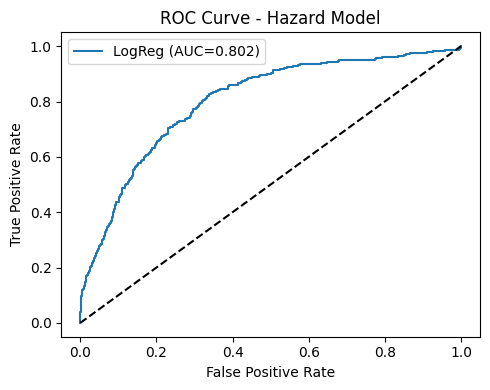

Validation AUC: 0.8218
Validation Brier Score: 0.1588
Concordance Index: 0.8289

Brier Score per bin:
390-420m: 0.0805
1350-1380m: 0.0000
840-870m: 0.1126
30-60m: 0.2245
0-30m: 0.2189
660-690m: 0.0302
60-180m: 0.2463
1110-1140m: 0.0001
420-450m: 0.0594
480-510m: 0.0765
1230-1260m: 0.0383
450-480m: 0.0822
240-270m: 0.1300
720-750m: 0.1029
600-630m: 0.0429
270-300m: 0.1236
510-540m: 0.0329
180-240m: 0.1846
360-390m: 0.0659
1200-1230m: 0.0792
870-900m: 0.0691
630-660m: 0.0152
930-960m: 0.0279
300-330m: 0.1076
330-360m: 0.1244
570-600m: 0.0422
990-1020m: 0.0541
1260-1290m: 0.1798
750-780m: 0.0177
1020-1050m: 0.0654
690-720m: 0.0687
1050-1080m: 0.1210
540-570m: 0.0680
810-840m: 0.0550
900-930m: 0.0269
780-810m: 0.0192
1170-1200m: 0.0000
1320-1350m: 0.0583
1380-1410m: 0.9952
1290-1320m: 0.0000
960-990m: 0.0527
1080-1110m: 0.0701
1140-1170m: 0.0001


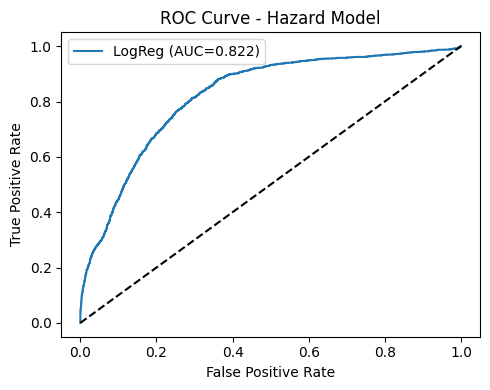

Top Features by Absolute Coefficient Magnitude:
                   Feature  Coefficient
                top3_share    -0.182553
         utilization_start    -0.136223
       utilization_current    -0.135570
                   bin_idx    -0.128323
                top1_share    -0.119680
avg_utilization_24h_before    -0.116191
        num_spikes_last_7d     0.055880
         borrow_rate_start    -0.032343
             rate_slope_1h     0.027011
       avg_rate_24h_before    -0.022170


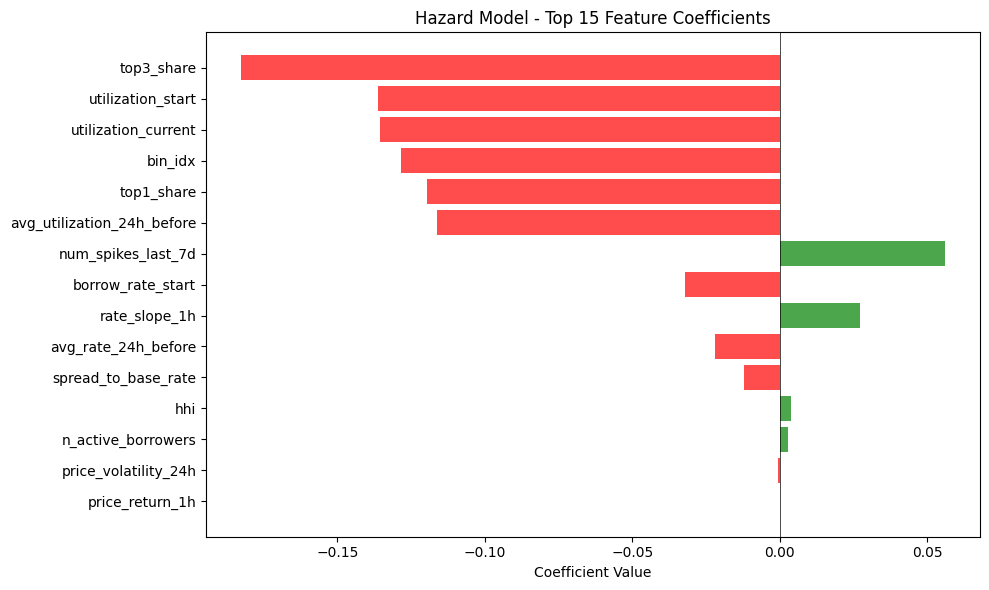

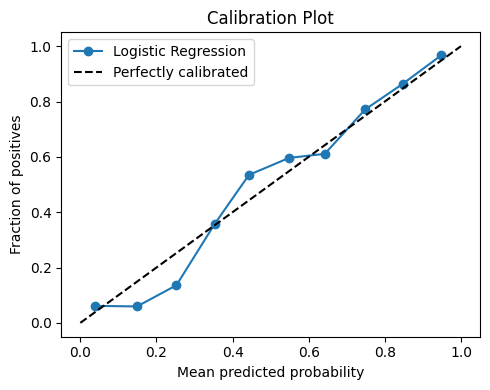

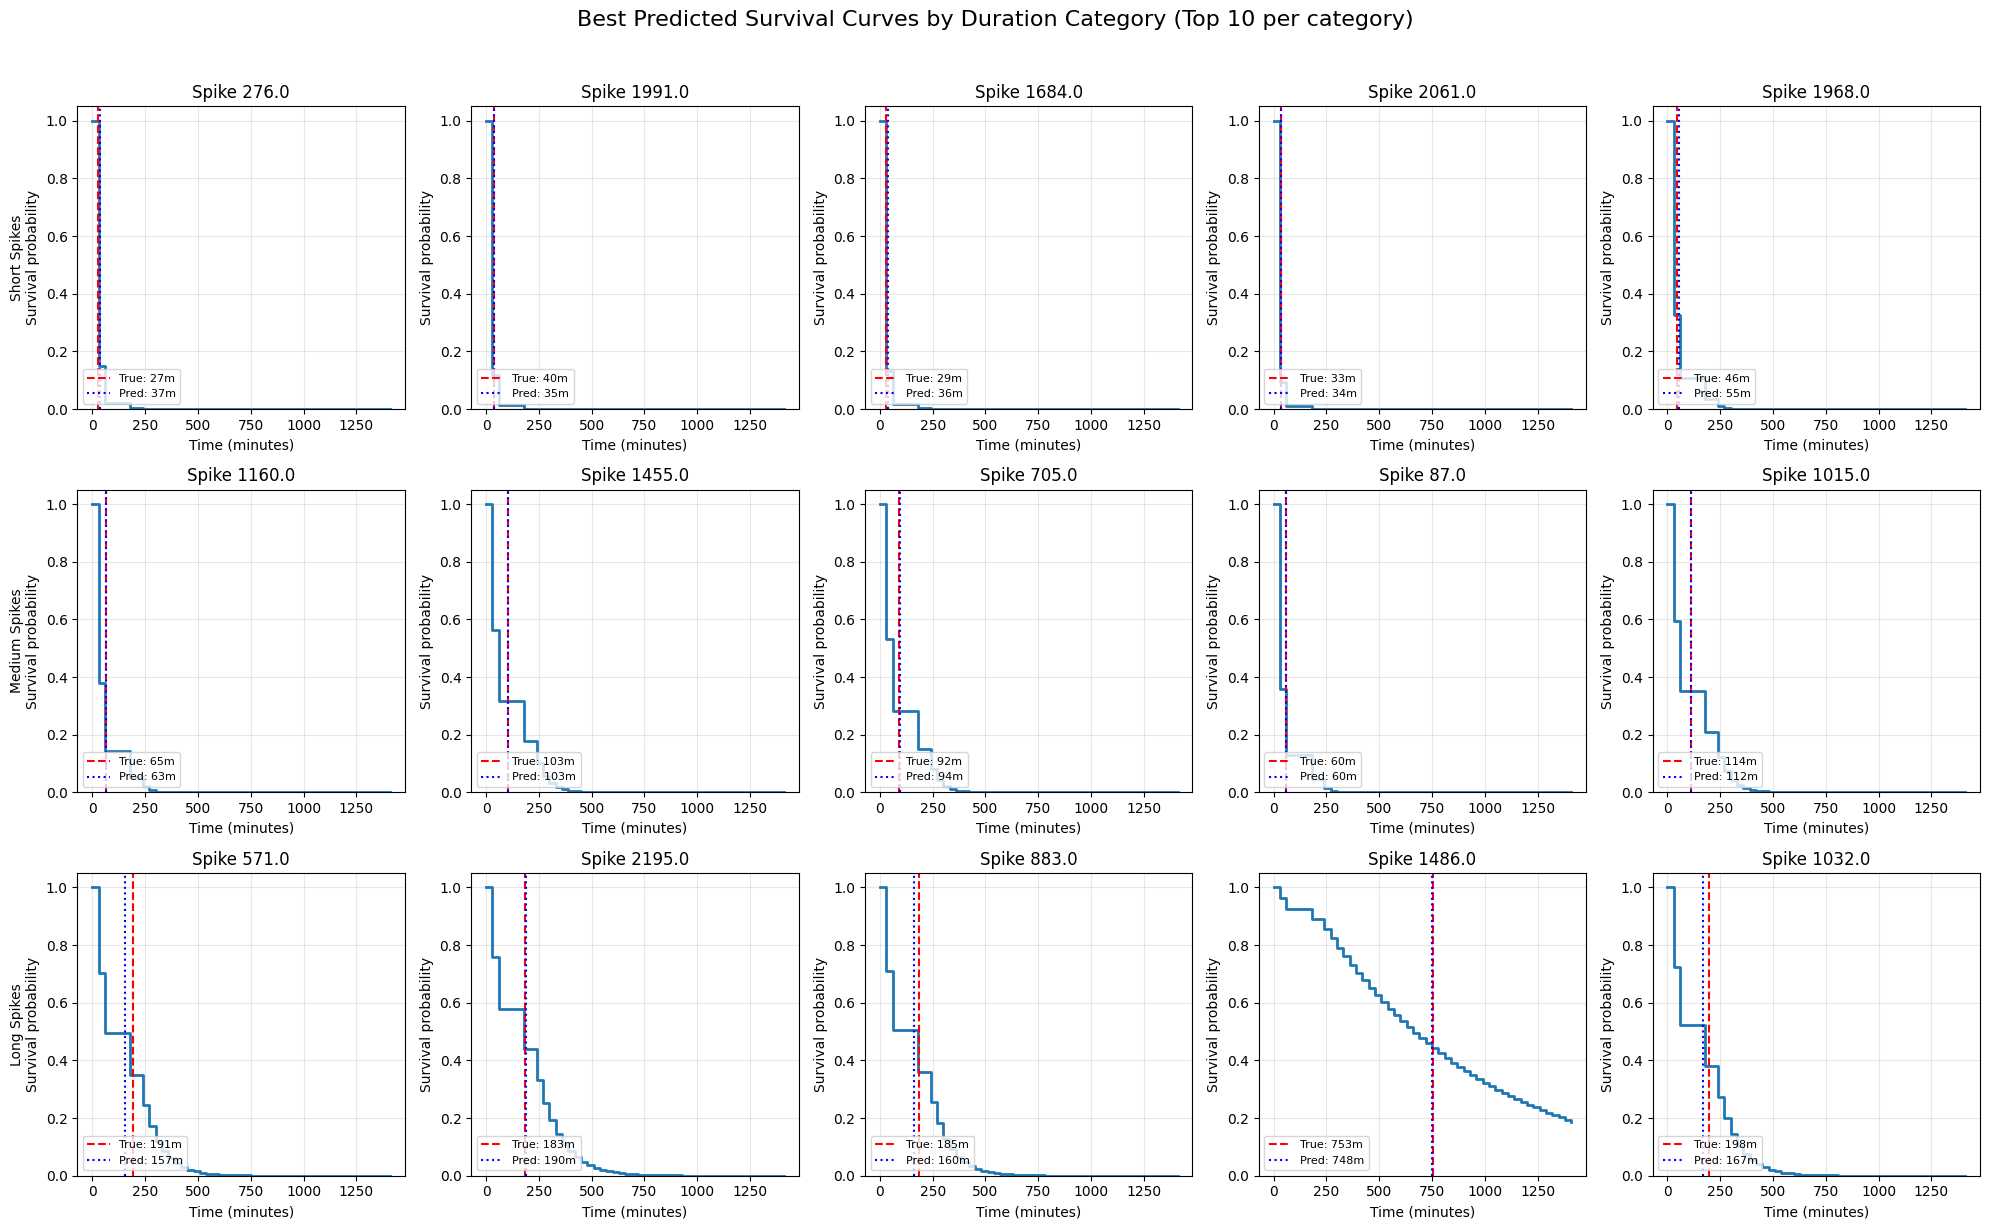

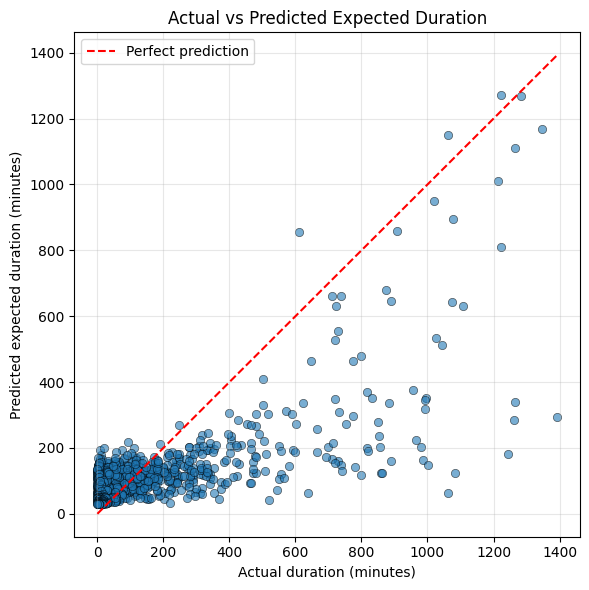

MAE of expected duration: 88.09 minutes
Survival Curve Slope (negative = decline) by Actual Duration:
              mean       50%       std
category                              
Long     -0.010899 -0.009964  0.004048
Medium   -0.007209 -0.007198  0.001693
Short    -0.006040 -0.006037  0.001531

Interpretation: More negative slope = faster decline (typical for short spikes).



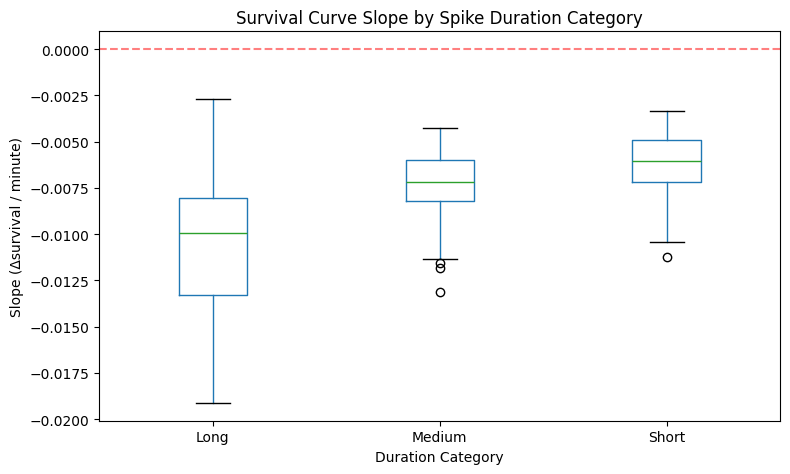

,slope,category
0,-0.013074,Long
1,-0.004019,Short
2,-0.008185,Short
3,-0.008668,Long
4,-0.005469,Medium
...,...,...
721,-0.006774,Short
722,-0.007024,Medium
723,-0.005616,Short
724,-0.006947,Medium


In [300]:
# df_prep = df.copy()
# df_prep = df_prep[
#     df_prep["spike_duration_seconds"] > 60*60 * 2
# ]
# df = pd.read_csv("/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/modelling_datasets/spikes_modeling_df_CRYPTO_tokens.csv")
# df = pd.read_csv("/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/modelling_datasets/spikes_modeling_df_YB_tokens.csv")
BINS_MINUTES = [0, 30, 60, 180, 240, 270, 300, 330, 360, 390, 420, 450, 480, 510, 540, 570, 600, 630, 660, 690, 720, 750, 780, 810, 840, 870, 900, 930, 960, 990, 1020, 1050, 1080, 1110, 1140, 1170, 1200, 1230, 1260, 1290, 1320, 1350, 1380, 1410]
# BINS_MINUTES = [0, 180, 270, 300, 330, 360, 390, 420, 450, 480, 510, 540, 570, 600, 630, 660, 690, 720, 750, 780, 810, 840, 870, 900, 930, 960, 990, 1020, 1050, 1080, 1110, 1140, 1170, 1200, 1230, 1260, 1290, 1320, 1350, 1380, 1410]

BIN_LABELS = []
for i in range(len(BINS_MINUTES)-1): BIN_LABELS.append(f"{BINS_MINUTES[i-1]}-{BINS_MINUTES[i]}m")


df = pd.read_csv("/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/modelling_datasets/spikes_modeling_df_PT_tokens.csv")
df_prep = df.copy()
# df_prep = df_prep[
#     df_prep["spike_duration_seconds"] > 60*60 * 2
# ]
hazard_df = prepare_hazard_dataset(df_prep, bins=BINS_MINUTES)

feature_cols = [
    'utilization_start', 'borrow_rate_start',
    'rate_slope_1h', 'spread_to_base_rate', 'total_borrow_current',
    'n_active_borrowers', 'top1_share', 'top3_share', 'hhi',
    'price_return_1h', 'price_volatility_24h', 'drawdown',
    'avg_utilization_24h_before', 'avg_rate_24h_before',
    'num_spikes_last_7d', 'time_since_last_spike',

    'utilization_current',
    # 'time_offset_minutes',
    'bin_idx',
    # 'utilization_peak_so_far',
]
X = hazard_df[feature_cols].fillna(0)
y = hazard_df['event']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
val_idx = X_val.index
hazard_val = hazard_df.loc[val_idx]
hazard_train = hazard_df.loc[X_train.index]

model = train_hazard_model(X_train, y_train)
y_pred_proba = evaluate_hazard_model(model, X_val, y_val, hazard_val)
y_pred_proba_train = evaluate_hazard_model(model, X_train, y_train, hazard_train)

display_hazard_model_coefficients(model, feature_cols)

# plot_calibration(y_val, y_pred_proba)
plot_calibration(y_train, y_pred_proba_train)

plot_survival_examples_grid_best_predictions(model, X_val, hazard_val, n_examples_per_row=5, bins=BINS_MINUTES)
# plot_kaplan_meier_style_comparison(model, X_val, hazard_val, bins=BINS_MINUTES)
plot_kaplan_meier_style_comparison(model, X_train, hazard_train, bins=BINS_MINUTES)


slopes, durations = compute_slopes_for_spikes(model, X_val, hazard_val, bins=BINS_MINUTES)
analyze_slopes_by_duration(slopes, durations)



Survival probability at 30 min by duration category:
              mean       50%       std
category                              
Long      0.720286  0.721271  0.170009
Medium    0.513061  0.536453  0.145033
Short     0.425607  0.462332  0.181878


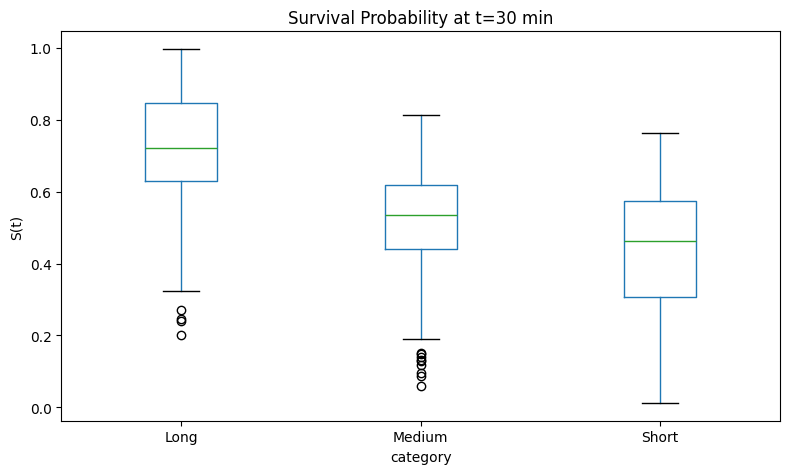


Survival probability at 120 min by duration category:
              mean       50%       std
category                              
Long      0.547594  0.520231  0.233851
Medium    0.284180  0.287784  0.133712
Short     0.214084  0.213751  0.139135


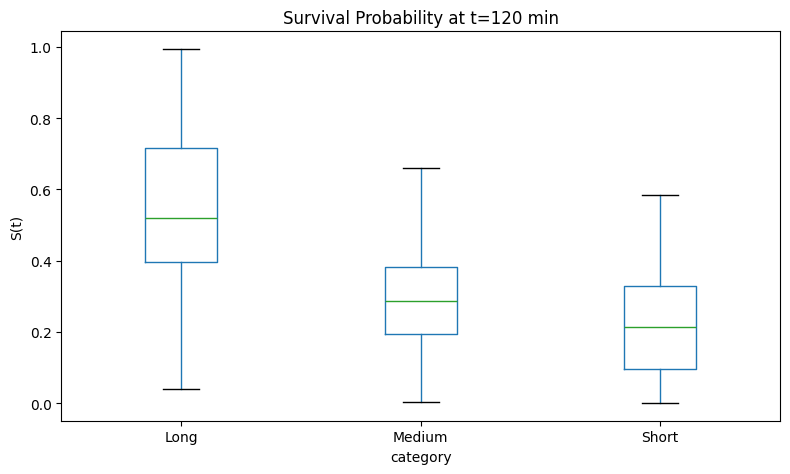


Survival probability at 360 min by duration category:
              mean       50%       std
category                              
Long      0.197987  0.073246  0.260261
Medium    0.015769  0.006860  0.023827
Short     0.008418  0.002088  0.014430


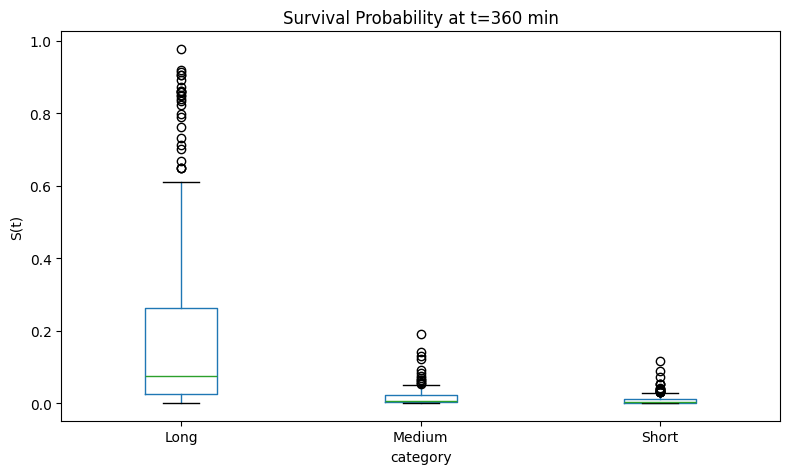

In [301]:
def analyze_survival_at_horizon(model, X_val, hazard_val, horizon_minutes, bins=BINS_MINUTES):
    unique_spikes = hazard_val[['spike_index', 'duration_minutes']].drop_duplicates()
    surv_at_horizon = []
    durations = []
    for _, spike in unique_spikes.iterrows():
        mask = hazard_val['spike_index'] == spike['spike_index']
        X_spike = X_val.loc[mask].iloc[[0]]
        times, surv = predict_survival_curve(model, X_spike, bins)
        idx = np.searchsorted(times, horizon_minutes, side='right') - 1
        if idx >= 0:
            surv_val = surv[idx]
        else:
            surv_val = 1.0
        surv_at_horizon.append(surv_val)
        durations.append(spike['duration_minutes'])

    durations = np.array(durations)
    surv_at_horizon = np.array(surv_at_horizon)

    short_threshold = np.percentile(durations, 33)
    long_threshold = np.percentile(durations, 67)
    categories = np.where(durations <= short_threshold, 'Short',
                 np.where(durations <= long_threshold, 'Medium', 'Long'))

    df_surv = pd.DataFrame({
        'survival': surv_at_horizon,
        'duration_minutes': durations,
        'category': categories
    })

    print(f"\nSurvival probability at {horizon_minutes} min by duration category:")
    print(df_surv.groupby('category')['survival'].describe()[['mean', '50%', 'std']])

    df_surv.boxplot(column='survival', by='category', grid=False, figsize=(8,5))
    plt.title(f'Survival Probability at t={horizon_minutes} min')
    plt.suptitle('')
    plt.ylabel('S(t)')
    plt.tight_layout()
    plt.show()
for horizon in [30, 120, 360]:
    analyze_survival_at_horizon(model, X_val, hazard_val, horizon)


In [317]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss, roc_auc_score, roc_curve
from lifelines.utils import concordance_index
import statsmodels.api as sm

BINNING_SCHEMES = {
    'fine_30m':       np.arange(0, 1441, 30),          # 0,30,60,...,1440
    'coarse_60m':     np.arange(0, 1441, 60),          # 0,60,120,...,1440
    'quantile_5bin':  [0, 33, 67, 140, 1440],          # event time quantiles
    'domain_sparse':  [0, 30, 120, 360, 1440]          # economic intervals
}

FEATURE_COLS = [
    'utilization_start', 'borrow_rate_start',
    'rate_slope_1h', 'spread_to_base_rate', 'total_borrow_current',
    'n_active_borrowers', 'top1_share', 'top3_share', 'hhi',
    'price_return_1h', 'price_volatility_24h', 'drawdown',
    'avg_utilization_24h_before', 'avg_rate_24h_before',
    'num_spikes_last_7d', 'time_since_last_spike',
    'utilization_current', 'bin_idx'
]

HORIZONS_MINUTES = [60, 60*2, 60*3, 60*6, 60*24]


def train_logistic_hazard(X_train, y_train):
    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_train, y_train)
    return model

def compute_ibs(y_true, y_pred):
    return brier_score_loss(y_true, y_pred)

def compute_calibration_slope(y_true, y_pred_proba):
    log_odds = np.log(np.clip(y_pred_proba, 1e-10, 1-1e-10)) - np.log(1 - np.clip(y_pred_proba, 1e-10, 1-1e-10))
    cal_model = LogisticRegression()
    cal_model.fit(log_odds.reshape(-1,1), y_true)
    return cal_model.coef_[0][0], cal_model.intercept_[0]

def compute_auc_at_horizon(hazard_df, y_pred_surv, horizon):
    true_surv = (hazard_df['duration_minutes'] > horizon).astype(int)
    return roc_auc_score(true_surv, y_pred_surv)

def compute_survival_at_horizon(model, X_spike, bins):
    """Return predicted survival at all bins for a single spike (row of X)."""
    bin_starts = bins[:-1]
    X_rep = pd.DataFrame(np.repeat(X_spike.values, len(bin_starts), axis=0), columns=X_spike.columns)
    prob_event = model.predict_proba(X_rep)[:, 1]
    surv = [1.0]
    for p in prob_event:
        surv.append(surv[-1] * (1 - p))
    return np.array(surv)  # length len(bins)

def evaluate_binning_scheme(df_long, bins, scheme_name, verbose=True):
    """Runs full evaluation for one binning scheme."""
    hazard_df = prepare_hazard_dataset(df_long, bins)
    hazard_df['bin_idx'] = hazard_df['bin_start'].apply(lambda x: list(bins[:-1]).index(x))
    
    X = hazard_df[FEATURE_COLS].fillna(0)
    y = hazard_df['event']
    
    # split with stratification on spikes to avoid leakage
    spike_indices = hazard_df['spike_index'].unique()
    train_spikes, val_spikes = train_test_split(spike_indices, test_size=0.2, random_state=42)
    train_mask = hazard_df['spike_index'].isin(train_spikes)
    val_mask = hazard_df['spike_index'].isin(val_spikes)
    
    X_train, y_train = X[train_mask], y[train_mask]
    X_val, y_val = X[val_mask], y[val_mask]
    hazard_train = hazard_df[train_mask]
    hazard_val = hazard_df[val_mask]
    
    model = train_logistic_hazard(X_train, y_train)
    y_pred_proba = model.predict_proba(X_val)[:, 1]
    
    # --- Overall metrics ---
    c_index = concordance_index(hazard_val['duration_minutes'], -y_pred_proba, y_val)
    ibs = compute_ibs(y_val, y_pred_proba)
    cal_slope, cal_intercept = compute_calibration_slope(y_val, y_pred_proba)
    
    # --- AUC at horizons ---
    # For AUC at horizon t, we need survival probability S(t) for each spike
    # We'll compute it per spike using the trained model
    val_spike_df = hazard_val[['spike_index', 'duration_minutes']].drop_duplicates()
    surv_preds = {h: [] for h in HORIZONS_MINUTES}
    for _, spike in val_spike_df.iterrows():
        spike_idx = spike['spike_index']
        mask = hazard_val['spike_index'] == spike_idx
        X_spike = X_val.loc[mask].iloc[[0]]
        surv_curve = compute_survival_at_horizon(model, X_spike, bins)
        for h in HORIZONS_MINUTES:
            idx = np.searchsorted(bins, h, side='right') - 1
            surv_preds[h].append(surv_curve[idx] if idx >= 0 else 1.0)
    
    auc_h = {}
    for h in HORIZONS_MINUTES:
        y_true_surv = (val_spike_df['duration_minutes'] > h).astype(int)
        auc_h[f'AUC_{h}min'] = roc_auc_score(y_true_surv, surv_preds[h])
    
    # --- Curve structure metrics ---
    durations = val_spike_df['duration_minutes'].values
    short_th = np.percentile(durations, 33)
    long_th = np.percentile(durations, 67)
    groups = {'Short': durations <= short_th,
              'Medium': (durations > short_th) & (durations <= long_th),
              'Long': durations > long_th}
    
    structure_metrics = {}
    for h in HORIZONS_MINUTES:
        surv_h = np.array(surv_preds[h])
        for gname, gmask in groups.items():
            structure_metrics[f'mean_S_{h}min_{gname}'] = np.mean(surv_h[gmask])
            structure_metrics[f'median_S_{h}min_{gname}'] = np.median(surv_h[gmask])
    
    # Time to S <= 0.5 (for each spike)
    half_life = []
    for _, spike in val_spike_df.iterrows():
        mask = hazard_val['spike_index'] == spike['spike_index']
        X_spike = X_val.loc[mask].iloc[[0]]
        surv_curve = compute_survival_at_horizon(model, X_spike, bins)
        times = bins
        idx = np.where(surv_curve <= 0.5)[0]
        half_life.append(times[idx[0]] if len(idx) > 0 else times[-1])
    half_life = np.array(half_life)
    for gname, gmask in groups.items():
        structure_metrics[f'median_half_life_{gname}'] = np.median(half_life[gmask])
    
    # --- Per‑bin Brier scores (optional) ---
    bin_brier = {}
    for bin_label in hazard_val['bin_label'].unique():
        mask_bin = hazard_val['bin_label'] == bin_label
        if mask_bin.sum() > 0:
            bin_brier[f'Bin_{bin_label}'] = brier_score_loss(y_val[mask_bin], y_pred_proba[mask_bin])
    
    results = {
        'scheme': scheme_name,
        'n_bins': len(bins)-1,
        'C_index': c_index,
        'IBS': ibs,
        'Calibration_slope': cal_slope,
        'Calibration_intercept': cal_intercept,
        **auc_h,
        **structure_metrics,
        **bin_brier
    }
    
    if verbose:
        print(f"\n--- {scheme_name} ({len(bins)-1} bins) ---")
        print(f"C-index: {c_index:.4f}, IBS: {ibs:.4f}, Calib slope: {cal_slope:.4f}")

        horizon_parts = [f"{h}min" for h in HORIZONS_MINUTES]
        auc_str = ", ".join([f"@{h}m: {auc_h[f'AUC_{h}min']:.3f}" for h in HORIZONS_MINUTES])
        print(f"AUC{auc_str}")

    
    return results, model, hazard_val

def run_full_experiment(df_long, schemes=BINNING_SCHEMES):
    all_results = []
    for name, bins in schemes.items():
        res, model, hazard_val = evaluate_binning_scheme(df_long, bins, name)
        all_results.append(res)
    results_df = pd.DataFrame(all_results)
    return results_df

df = pd.read_csv("/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/modelling_datasets/spikes_modeling_df_PT_tokens.csv")
# df = pd.read_csv("/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/modelling_datasets/spikes_modeling_df_YB_tokens.csv")
# df = pd.read_csv("/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/modelling_datasets/spikes_modeling_df_CRYPTO_tokens.csv")

results_table = run_full_experiment(df)

# Select columns for the main comparison table
horizon_cols = [f'AUC_{h}min' for h in HORIZONS_MINUTES]
main_cols = ['scheme', 'n_bins', 'C_index', 'IBS', 'Calibration_slope'] + horizon_cols
main_table = results_table[main_cols]
print(main_table.to_string(index=False))




--- fine_30m (48 bins) ---
C-index: 0.8485, IBS: 0.1506, Calib slope: 0.8923
AUC@60m: 0.702, @120m: 0.715, @180m: 0.720, @360m: 0.724, @1440m: 0.948

--- coarse_60m (24 bins) ---
C-index: 0.8166, IBS: 0.1784, Calib slope: 1.0039
AUC@60m: 0.723, @120m: 0.745, @180m: 0.747, @360m: 0.778, @1440m: 0.953

--- quantile_5bin (4 bins) ---
C-index: 0.6107, IBS: 0.1931, Calib slope: 1.0733
AUC@60m: 0.723, @120m: 0.738, @180m: 0.743, @360m: 0.772, @1440m: 0.946

--- domain_sparse (4 bins) ---
C-index: 0.6593, IBS: 0.2148, Calib slope: 1.1864
AUC@60m: 0.725, @120m: 0.742, @180m: 0.742, @360m: 0.772, @1440m: 0.959
       scheme  n_bins  C_index      IBS  Calibration_slope  AUC_60min  AUC_120min  AUC_180min  AUC_360min  AUC_1440min
     fine_30m      48 0.848510 0.150565           0.892287   0.701548    0.715164    0.719936    0.723648     0.948368
   coarse_60m      24 0.816618 0.178401           1.003895   0.722667    0.744931    0.747004    0.777882     0.952923
quantile_5bin       4 0.610677 0.

Figure saved to survival_curves_paper.pdf


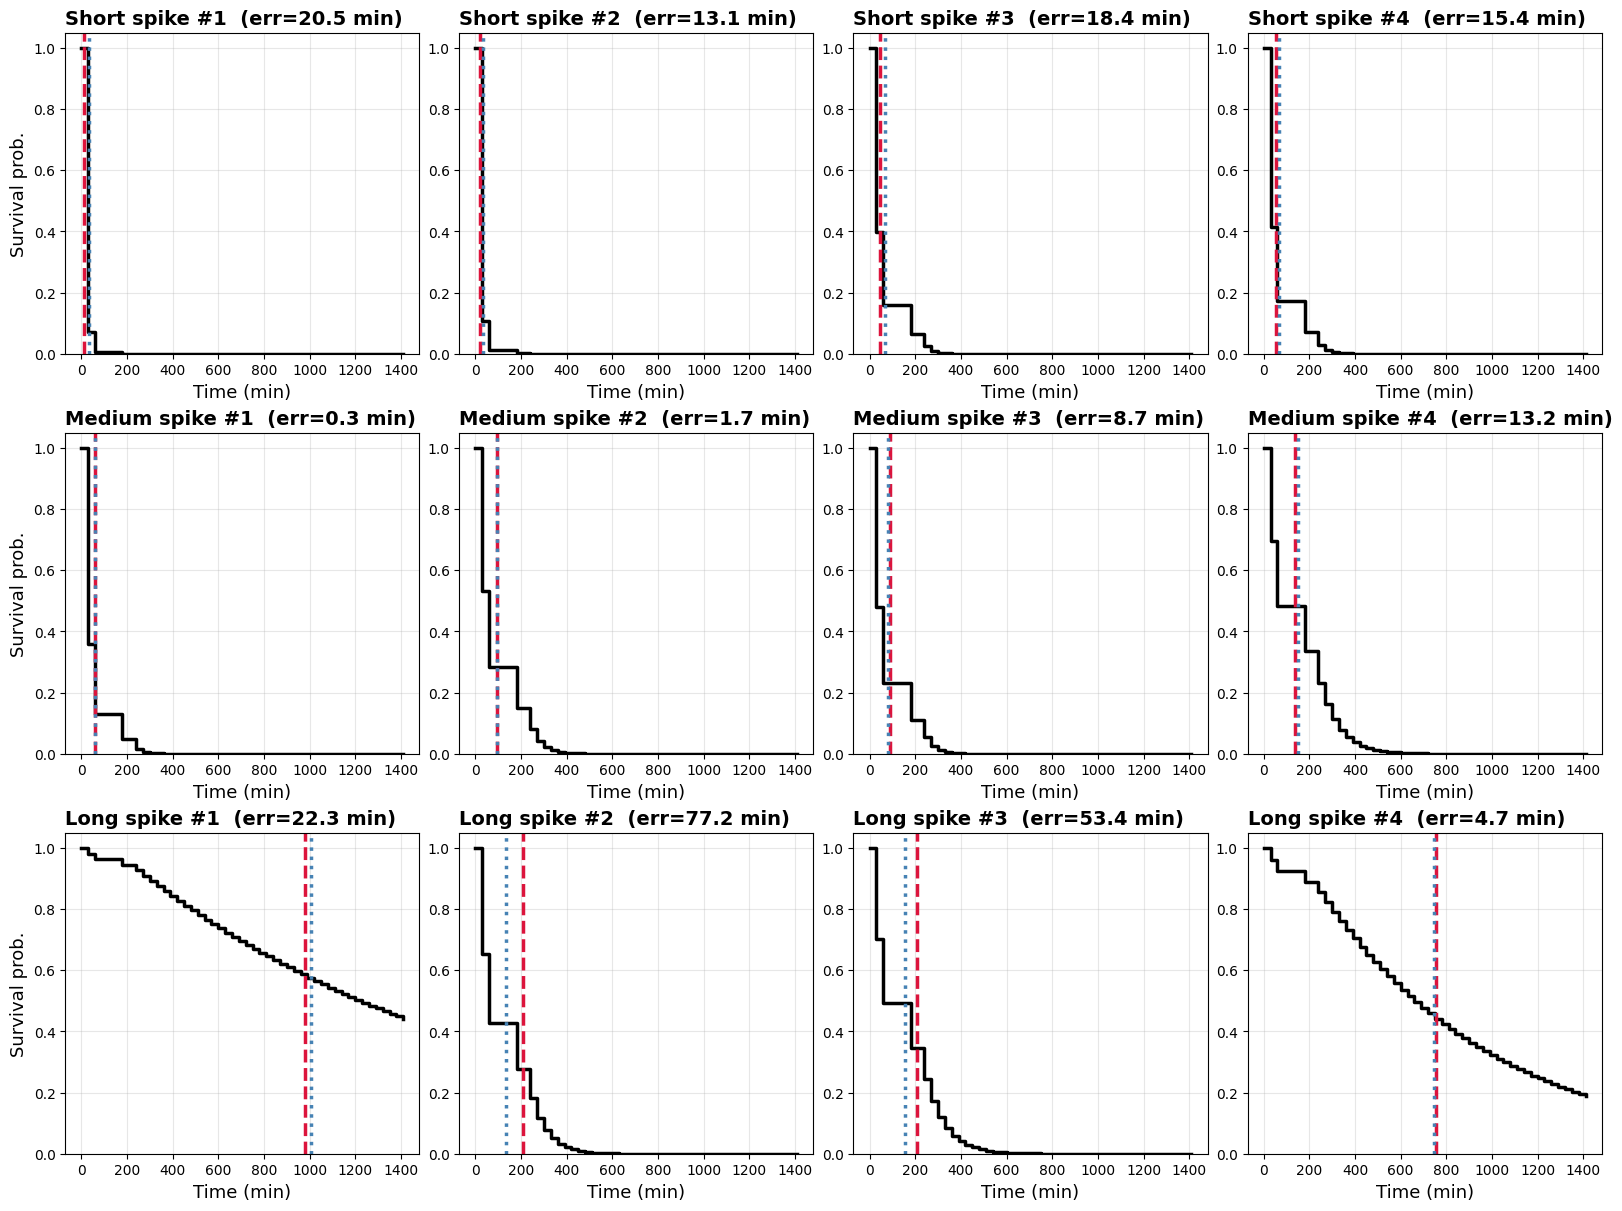

In [320]:
def plot_survival_examples_paper(
    model,
    X_val,
    hazard_val,
    bins,
    n_examples_per_row=5,
    short_threshold=60,
    long_threshold=180,
    random_state=42,
    save_path=None,
):
    """
    Plot best-predicted survival curves for short, medium, and long spikes.

    For each duration category, picks the top 10 spikes with smallest absolute
    error between expected and true duration, then randomly selects `n_examples_per_row`
    to display. Produces a 3 x n_examples_per_row grid, publication‑ready styling.

    Parameters
    ----------
    model : fitted logistic regression model (predict_proba)
    X_val : DataFrame of validation features (aligned with hazard_val)
    hazard_val : DataFrame from prepare_hazard_dataset, must contain
                 spike_index, duration_minutes
    bins : array-like, bin boundaries (e.g., [0,30,120,360,1440])
    n_examples_per_row : int, columns per row (default 5)
    short_threshold : float, minutes; spikes ≤ this are 'Short'
    long_threshold : float, minutes; spikes > this are 'Long'
    random_state : int, for reproducible sampling
    save_path : str or None, if given saves the figure to this path
    """
    # Compute predictions and errors for all unique spikes
    unique_spikes = hazard_val[['spike_index', 'duration_minutes']].drop_duplicates()

    spike_errors = []
    for _, spike_row in unique_spikes.iterrows():
        spike_idx = spike_row['spike_index']
        true_duration = spike_row['duration_minutes']
        mask = hazard_val['spike_index'] == spike_idx
        X_spike = X_val.loc[mask].iloc[[0]]
        pred_duration = predict_expected_duration(model, X_spike, bins)
        error = abs(true_duration - pred_duration)
        spike_errors.append({
            'spike_index': spike_idx,
            'duration_minutes': true_duration,
            'pred_duration': pred_duration,
            'abs_error': error,
        })

    errors_df = pd.DataFrame(spike_errors)

    # Categorise
    errors_df['category'] = 'Medium'
    errors_df.loc[errors_df['duration_minutes'] <= short_threshold, 'category'] = 'Short'
    errors_df.loc[errors_df['duration_minutes'] > long_threshold, 'category'] = 'Long'

    # Pick top-10 best in each category, then sample
    cnt=30
    best_short = errors_df[errors_df['category'] == 'Short'].nsmallest(cnt, 'abs_error')
    best_medium = errors_df[errors_df['category'] == 'Medium'].nsmallest(cnt, 'abs_error')
    best_long = errors_df[errors_df['category'] == 'Long'].nsmallest(cnt, 'abs_error')

    np.random.seed(random_state)
    sample_short = best_short.sample(n=min(n_examples_per_row, len(best_short)))
    sample_medium = best_medium.sample(n=min(n_examples_per_row, len(best_medium)))
    sample_long = best_long.sample(n=min(n_examples_per_row, len(best_long)))

    spike_groups = [sample_short, sample_medium, sample_long]
    row_labels = ['Short', 'Medium', 'Long']

    # Publication style
    plt.rcParams.update({
        'font.size': 12,
        'axes.titlesize': 14,
        'axes.labelsize': 13,
        'legend.fontsize': 10,
        'xtick.labelsize': 10,
        'ytick.labelsize': 10,
        'lines.linewidth': 2,
    })

    fig, axes = plt.subplots(3, n_examples_per_row,
                             figsize=(4 * n_examples_per_row, 12),
                             constrained_layout=True)

    # Define colours and line styles
    color_surv = 'black'
    color_true = 'crimson'
    color_pred = 'steelblue'
    ls_true = '--'
    ls_pred = ':'
    lw_true = 2.5
    lw_pred = 2.5
    lw_surv = 2.5

    for row_idx, (sample, label) in enumerate(zip(spike_groups, row_labels)):
        n_sample = len(sample)
        for col_idx in range(n_examples_per_row):
            ax = axes[row_idx, col_idx]
            if col_idx >= n_sample:
                ax.set_visible(False)
                continue

            spike_row = sample.iloc[col_idx]
            spike_idx = spike_row['spike_index']
            true_duration = spike_row['duration_minutes']
            pred_duration = spike_row['pred_duration']
            error = spike_row['abs_error']

            mask = hazard_val['spike_index'] == spike_idx
            X_spike = X_val.loc[mask].iloc[[0]]
            times, surv = predict_survival_curve(model, X_spike, bins)

            # Plot survival curve
            ax.step(times, surv, where='post', color=color_surv, linewidth=lw_surv, label='Predicted survival')

            # Mark true and predicted durations
            ax.axvline(true_duration, color=color_true, linestyle=ls_true, linewidth=lw_true,
                       label=f'True: {true_duration:.0f} min')
            ax.axvline(pred_duration, color=color_pred, linestyle=ls_pred, linewidth=lw_pred,
                       label=f'Pred: {pred_duration:.0f} min')

            ax.set_xlabel('Time (min)')
            ax.set_ylabel('Survival prob.' if col_idx == 0 else '')
            ax.set_title(f'{label} spike #{col_idx+1}  (err={error:.1f} min)', loc='left', fontweight='bold')
            ax.grid(True, alpha=0.3)
            ax.set_ylim(0, 1.05)

    # Single legend at the top of the figure
    handles, labels = axes[0, 0].get_legend_handles_labels()

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved to {save_path}")

    plt.show()
    return fig


fig = plot_survival_examples_paper(
    model=model,
    X_val=X_val,
    hazard_val=hazard_val,
    bins=BINS_MINUTES,               # your bin array
    n_examples_per_row=4,            # or 3 or 5
    short_threshold=60,              # ≤60 min = Short
    long_threshold=180,              # >180 min = Long
    random_state=42,
    save_path='survival_curves_paper.pdf'
)


In [316]:
df['spike_duration_seconds'].describe()

count    2.840500e+04
mean     2.434632e+05
std      2.361221e+05
min      0.000000e+00
25%      6.243600e+04
50%      1.509960e+05
75%      3.824880e+05
max      1.118772e+06
Name: spike_duration_seconds, dtype: float64

In [201]:
hazard_df[hazard_df['spike_index'] == 2540]

,market,spike_index,time_offset_minutes,utilization_start,utilization_current,utilization_peak_so_far,borrow_rate_start,rate_slope_1h,spread_to_base_rate,total_borrow_current,n_active_borrowers,top1_share,top3_share,hhi,price_return_1h,price_volatility_24h,drawdown,avg_utilization_24h_before,avg_rate_24h_before,num_spikes_last_7d,time_since_last_spike,remaining_duration_seconds,spike_duration_seconds,cutoff_timestamp,spike_trigger_timestamp,duration_minutes,bin_start,bin_end,bin_label,event
11,eth_PT-reUSD-25JUN2026_usdc,2540,0.0,0.961259,0.961259,0.961259,0.195734,0.0,0.086472,1.282164e+07,13,0.440667,0.911434,0.322615,0.000000,0.001962,0.000787,0.915225,0.099344,2,109716.0,10104.0,10104,1.766019e+09,1.766019e+09,168.4,0,30,0-30m,0
12,eth_PT-reUSD-25JUN2026_usdc,2540,30.0,0.961259,0.961259,0.961259,0.195734,0.0,0.086472,1.282164e+07,13,0.440667,0.911434,0.322615,-0.000295,0.001919,0.001082,0.915225,0.099344,2,109716.0,8304.0,10104,1.766021e+09,1.766019e+09,168.4,30,60,30-60m,0
13,eth_PT-reUSD-25JUN2026_usdc,2540,60.0,0.961259,0.961259,0.961259,0.195734,0.0,0.086472,1.282164e+07,13,0.440667,0.911434,0.322615,-0.000295,0.001919,0.001082,0.915225,0.099344,2,109716.0,6504.0,10104,1.766023e+09,1.766019e+09,168.4,60,180,60-180m,1


In [216]:
spikes_util_diffs = {}
fields_list = ['utilization_current', 'hhi', 'top3_share', 'top1_share', 'total_borrow_current']
for f in fields_list: spikes_util_diffs[f] = []
for i in hazard_df['spike_index'].unique():
    for field in fields_list:
        # print(hazard_df[hazard_df['spike_index'] == i].shape)
        lst = list(hazard_df[hazard_df['spike_index'] == i][field])[0]
        data = list(hazard_df[(hazard_df['spike_index'] == i) & (hazard_df['event'] == 0)][field] - lst)[1:]
        if len(data) == 0:
            continue
        spikes_util_diffs[field].append(np.mean(data))
        # print(spikes_util_diffs)


utilization_current
count    499.000000
mean      -0.011021
std        0.023022
min       -0.096623
25%       -0.015047
50%        0.000000
75%        0.000000
max        0.033820
dtype: float64


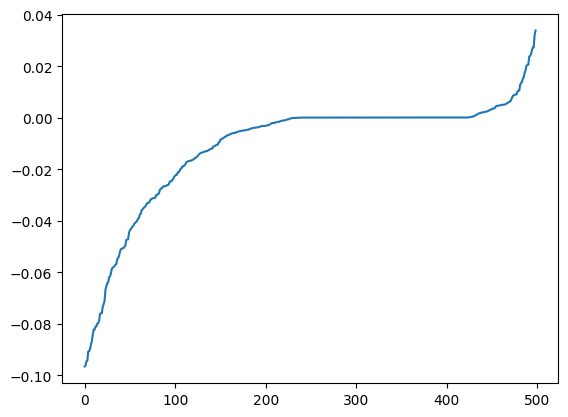

hhi
count    499.000000
mean       0.000136
std        0.008215
min       -0.098738
25%        0.000000
50%        0.000000
75%        0.000000
max        0.098670
dtype: float64


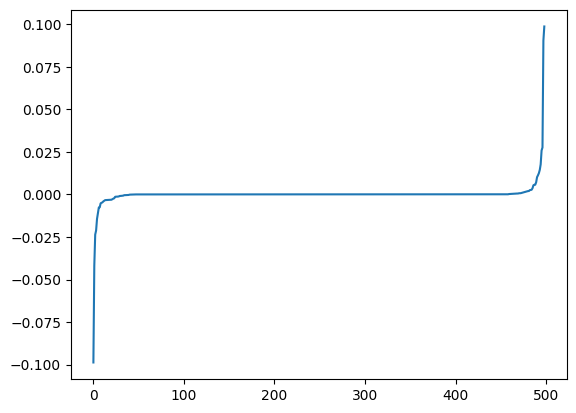

top3_share
count    499.000000
mean      -0.000407
std        0.007110
min       -0.114044
25%        0.000000
50%        0.000000
75%        0.000000
max        0.028968
dtype: float64


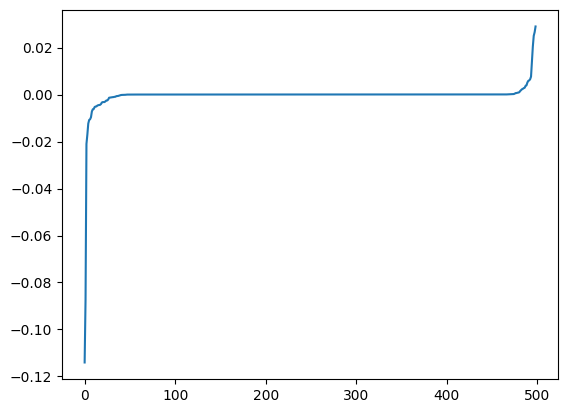

top1_share
count    499.000000
mean      -0.000056
std        0.011598
min       -0.164109
25%        0.000000
50%        0.000000
75%        0.000000
max        0.116392
dtype: float64


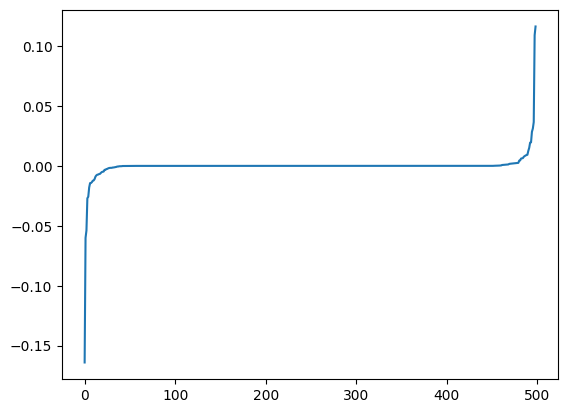

total_borrow_current
count    4.990000e+02
mean    -1.908458e+04
std      2.960393e+05
min     -2.831152e+06
25%      0.000000e+00
50%      7.108359e+00
75%      1.196789e+02
max      2.836898e+06
dtype: float64


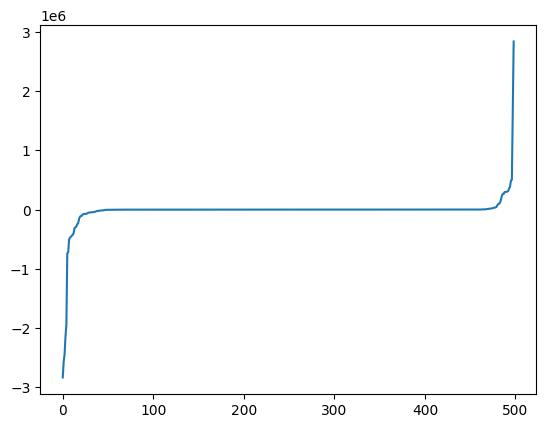

In [217]:
for f in fields_list:
    print(f)
    print(pd.Series(spikes_util_diffs[f]).describe())
    pd.Series(sorted(spikes_util_diffs[f])).plot()
    plt.show()
